In [2]:
import pandas as pd

# dataset
file_path = "./demanddata_2024.csv"
df = pd.read_csv(file_path)


df.info(), df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17568 entries, 0 to 17567
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   SETTLEMENT_DATE            17568 non-null  object
 1   SETTLEMENT_PERIOD          17568 non-null  int64 
 2   ND                         17568 non-null  int64 
 3   TSD                        17568 non-null  int64 
 4   ENGLAND_WALES_DEMAND       17568 non-null  int64 
 5   EMBEDDED_WIND_GENERATION   17568 non-null  int64 
 6   EMBEDDED_WIND_CAPACITY     17568 non-null  int64 
 7   EMBEDDED_SOLAR_GENERATION  17568 non-null  int64 
 8   EMBEDDED_SOLAR_CAPACITY    17568 non-null  int64 
 9   NON_BM_STOR                17568 non-null  int64 
 10  PUMP_STORAGE_PUMPING       17568 non-null  int64 
 11  SCOTTISH_TRANSFER          17568 non-null  int64 
 12  IFA_FLOW                   17568 non-null  int64 
 13  IFA2_FLOW                  17568 non-null  int64 
 14  BRITNE

(None,
   SETTLEMENT_DATE  SETTLEMENT_PERIOD     ND    TSD  ENGLAND_WALES_DEMAND  \
 0     01-JAN-2024                  1  21783  23466                 19539   
 1     01-JAN-2024                  2  22521  24103                 20286   
 2     01-JAN-2024                  3  22194  24754                 20070   
 3     01-JAN-2024                  4  21510  24505                 19424   
 4     01-JAN-2024                  5  20619  23977                 18674   
 
    EMBEDDED_WIND_GENERATION  EMBEDDED_WIND_CAPACITY  \
 0                      2804                    6488   
 1                      2834                    6488   
 2                      2868                    6488   
 3                      2901                    6488   
 4                      2933                    6488   
 
    EMBEDDED_SOLAR_GENERATION  EMBEDDED_SOLAR_CAPACITY  NON_BM_STOR  ...  \
 0                          0                    16793            0  ...   
 1                          0          

In [3]:
# Convert SETTLEMENT_DATE to datetime format
df["SETTLEMENT_DATE"] = pd.to_datetime(df["SETTLEMENT_DATE"], format="%d-%b-%Y")

# Create a DATETIME column combining date and settlement period (each period represents 30 mins)
df["DATETIME"] = df["SETTLEMENT_DATE"] + pd.to_timedelta((df["SETTLEMENT_PERIOD"] - 1) * 30, unit="m")

# Drop unnecessary columns for initial modeling (keeping main demand-related fields)
columns_to_keep = ["DATETIME", "ND", "TSD", "ENGLAND_WALES_DEMAND"]
df_cleaned = df[columns_to_keep].sort_values(by="DATETIME")

# Check for negative or anomalous demand values
# Check for negative values only in numerical columns
numerical_cols = df_cleaned.select_dtypes(include=["number"])
negative_values = (numerical_cols < 0).sum()


df_cleaned.head(), negative_values


(             DATETIME     ND    TSD  ENGLAND_WALES_DEMAND
 0 2024-01-01 00:00:00  21783  23466                 19539
 1 2024-01-01 00:30:00  22521  24103                 20286
 2 2024-01-01 01:00:00  22194  24754                 20070
 3 2024-01-01 01:30:00  21510  24505                 19424
 4 2024-01-01 02:00:00  20619  23977                 18674,
 ND                      0
 TSD                     0
 ENGLAND_WALES_DEMAND    0
 dtype: int64)

In [4]:
# Check for negative values only in numerical columns
negative_values = (df_cleaned.select_dtypes(include=['int64', 'float64']) < 0).sum()

# Display cleaned data and negative value counts
df_cleaned.head(), negative_values


(             DATETIME     ND    TSD  ENGLAND_WALES_DEMAND
 0 2024-01-01 00:00:00  21783  23466                 19539
 1 2024-01-01 00:30:00  22521  24103                 20286
 2 2024-01-01 01:00:00  22194  24754                 20070
 3 2024-01-01 01:30:00  21510  24505                 19424
 4 2024-01-01 02:00:00  20619  23977                 18674,
 ND                      0
 TSD                     0
 ENGLAND_WALES_DEMAND    0
 dtype: int64)

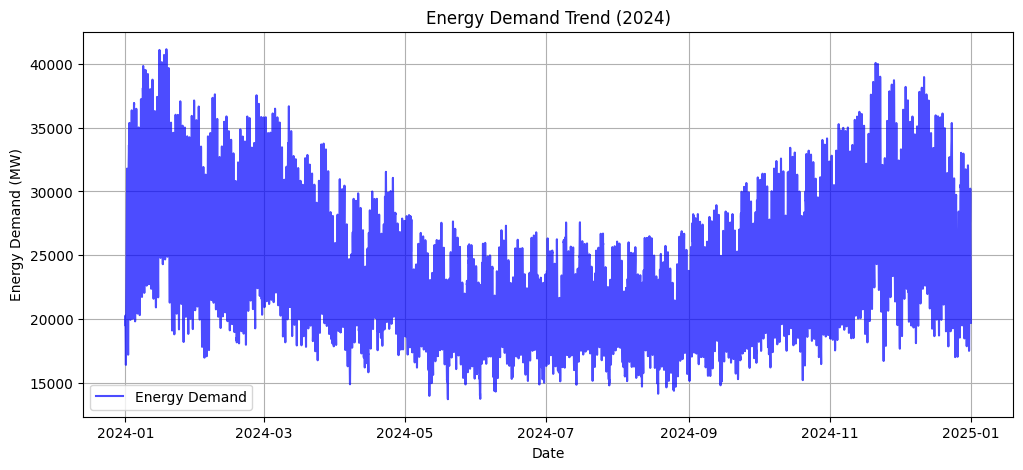

In [5]:
import matplotlib.pyplot as plt

# Plot overall energy demand trend
plt.figure(figsize=(12, 5))
plt.plot(df_cleaned["DATETIME"], df_cleaned["ENGLAND_WALES_DEMAND"], label="Energy Demand", color="blue", alpha=0.7)
plt.xlabel("Date")
plt.ylabel("Energy Demand (MW)")
plt.title("Energy Demand Trend (2024)")
plt.legend()
plt.grid()
plt.show()


C:\Users\DELL\AppData\Local\Temp\ipykernel_33900\3395728471.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="DAY_OF_WEEK", y="ENGLAND_WALES_DEMAND", data=df_cleaned, order=[


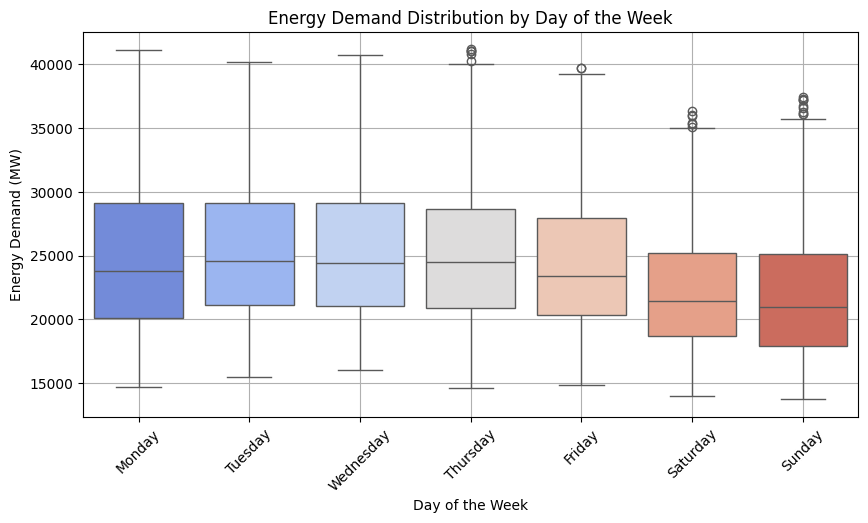

In [6]:
import seaborn as sns

# Extract day of the week and hour for analysis
df_cleaned["DAY_OF_WEEK"] = df_cleaned["DATETIME"].dt.day_name()
df_cleaned["HOUR"] = df_cleaned["DATETIME"].dt.hour

# Average demand by day of the week
plt.figure(figsize=(10, 5))
sns.boxplot(x="DAY_OF_WEEK", y="ENGLAND_WALES_DEMAND", data=df_cleaned, order=[
    "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"
], palette="coolwarm")
plt.xlabel("Day of the Week")
plt.ylabel("Energy Demand (MW)")
plt.title("Energy Demand Distribution by Day of the Week")
plt.xticks(rotation=45)
plt.grid()
plt.show()


C:\Users\DELL\AppData\Local\Temp\ipykernel_33900\760260818.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="HOUR", y="ENGLAND_WALES_DEMAND", data=df_cleaned, palette="viridis")


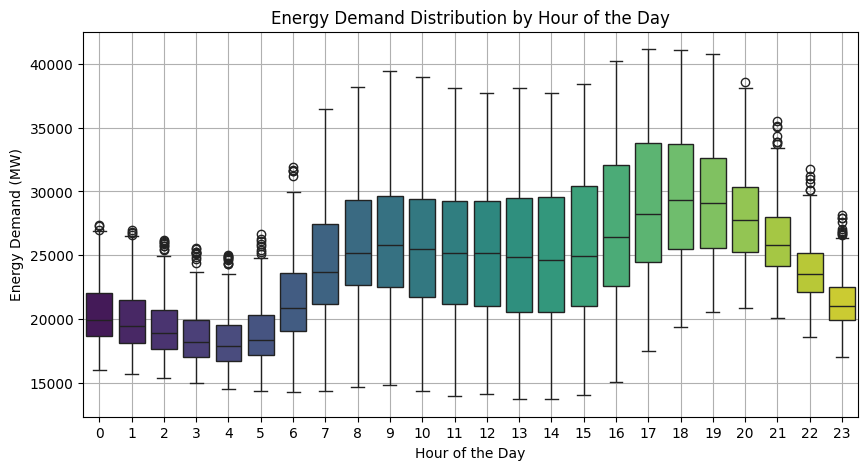

In [7]:
# Average demand by hour of the day
plt.figure(figsize=(10, 5))
sns.boxplot(x="HOUR", y="ENGLAND_WALES_DEMAND", data=df_cleaned, palette="viridis")
plt.xlabel("Hour of the Day")
plt.ylabel("Energy Demand (MW)")
plt.title("Energy Demand Distribution by Hour of the Day")
plt.grid()
plt.show()


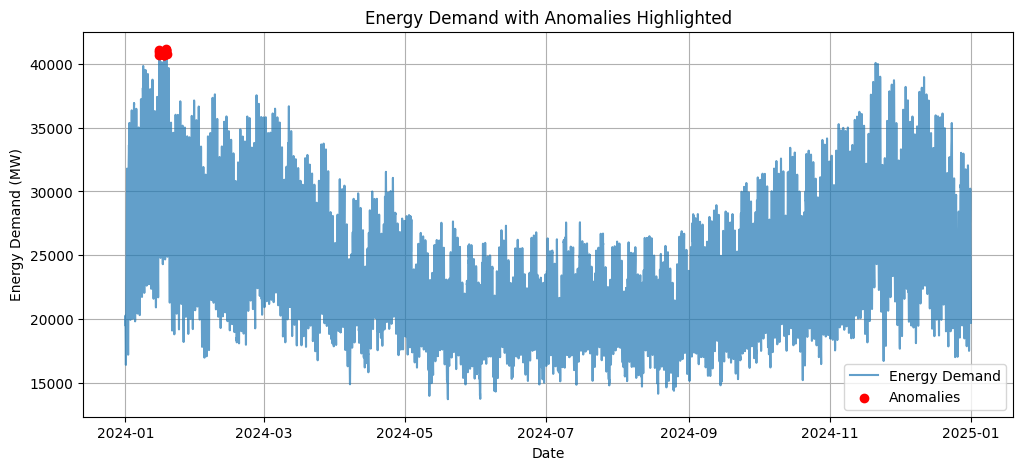

,DATETIME,ND,TSD,ENGLAND_WALES_DEMAND,DAY_OF_WEEK,HOUR,Z_SCORE
706,2024-01-15 17:00:00,44989,46760,40929,Monday,17,3.079865
707,2024-01-15 17:30:00,45202,46976,41074,Monday,17,3.106498
708,2024-01-15 18:00:00,44761,46482,40682,Monday,18,3.034497
802,2024-01-17 17:00:00,44744,46340,40665,Wednesday,17,3.031375
803,2024-01-17 17:30:00,44768,46359,40682,Wednesday,17,3.034497


In [8]:
from scipy.stats import zscore

# Compute Z-scores to detect anomalies
df_cleaned["Z_SCORE"] = zscore(df_cleaned["ENGLAND_WALES_DEMAND"])

# Define threshold for anomaly detection (e.g., Z-score > 3 or < -3)
anomalies = df_cleaned[abs(df_cleaned["Z_SCORE"]) > 3]

# Plot anomalies on the demand trend
plt.figure(figsize=(12, 5))
plt.plot(df_cleaned["DATETIME"], df_cleaned["ENGLAND_WALES_DEMAND"], label="Energy Demand", alpha=0.7)
plt.scatter(anomalies["DATETIME"], anomalies["ENGLAND_WALES_DEMAND"], color="red", label="Anomalies", zorder=3)
plt.xlabel("Date")
plt.ylabel("Energy Demand (MW)")
plt.title("Energy Demand with Anomalies Highlighted")
plt.legend()
plt.grid()
plt.show()

# Display the first few detected anomalies
anomalies.head()


In [9]:
print(df_cleaned.columns)


Index(['DATETIME', 'ND', 'TSD', 'ENGLAND_WALES_DEMAND', 'DAY_OF_WEEK', 'HOUR',
       'Z_SCORE'],
      dtype='object')


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np


# Ensure DATETIME is in datetime format
df_cleaned["DATETIME"] = pd.to_datetime(df_cleaned["DATETIME"])

# Create time-based features
df_cleaned["HOUR"] = df_cleaned["DATETIME"].dt.hour
df_cleaned["WEEKDAY"] = df_cleaned["DATETIME"].dt.weekday  # 0=Monday, 6=Sunday
df_cleaned["MONTH"] = df_cleaned["DATETIME"].dt.month

# Create lag features
df_cleaned["LAG_1H"] = df_cleaned["ENGLAND_WALES_DEMAND"].shift(1)
df_cleaned["LAG_1D"] = df_cleaned["ENGLAND_WALES_DEMAND"].shift(48)  # Assuming 30-min intervals (48 per day)

# Drop NaN values created by shifting
df_cleaned.dropna(inplace=True)


# Define features and target variable
features = ["HOUR", "WEEKDAY", "MONTH", "LAG_1H", "LAG_1D"]
target = "ENGLAND_WALES_DEMAND"

# Split data into training and testing sets (80% train, 20% test)
# X_train, X_test, y_train, y_test = train_test_split(df_cleaned[features], df_cleaned[target], test_size=0.2, random_state=42, shuffle=False)
X_train, X_test, y_train, y_test = train_test_split(
    df_cleaned[["HOUR", "WEEKDAY", "MONTH", "LAG_1H", "LAG_1D"]], 
    df_cleaned["ENGLAND_WALES_DEMAND"], 
    test_size=0.2, 
    random_state=42, 
    shuffle=False
)




# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Ridge Regression Model
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)
ridge_preds = ridge_model.predict(X_test_scaled)

# Train Lasso Regression Model
lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_train_scaled, y_train)
lasso_preds = lasso_model.predict(X_test_scaled)

# Train Random Forest Model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

# Evaluate models using MAE and RMSE
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return f"{model_name}: MAE = {mae:.2f}, RMSE = {rmse:.2f}"

ridge_eval = evaluate_model(y_test, ridge_preds, "Ridge Regression")
lasso_eval = evaluate_model(y_test, lasso_preds, "Lasso Regression")
rf_eval = evaluate_model(y_test, rf_preds, "Random Forest")

ridge_eval, lasso_eval, rf_eval


('Ridge Regression: MAE = 655.08, RMSE = 809.56',
 'Lasso Regression: MAE = 655.20, RMSE = 809.66',
 'Random Forest: MAE = 358.51, RMSE = 476.20')

# 📘 Electricity Demand Forecasting & Efficiency Analysis
A Final Year Project using Machine Learning & Deep Learning

---


## 1. 🧼 Data Preprocessing & Feature Engineering
This section prepares the NESO energy demand data by converting timestamps, handling anomalies, and creating lagged features for modeling.

In [11]:
# Convert SETTLEMENT_DATE to datetime
df["SETTLEMENT_DATE"] = pd.to_datetime(df["SETTLEMENT_DATE"], format="%d-%b-%Y")
df["DATETIME"] = df["SETTLEMENT_DATE"] + pd.to_timedelta((df["SETTLEMENT_PERIOD"] - 1) * 30, unit="m")
df = df.sort_values("DATETIME")

# Add time features
df["HOUR"] = df["DATETIME"].dt.hour
df["WEEKDAY"] = df["DATETIME"].dt.weekday
df["MONTH"] = df["DATETIME"].dt.month

# Create lag features
df["LAG_1H"] = df["ENGLAND_WALES_DEMAND"].shift(2)
df["LAG_1D"] = df["ENGLAND_WALES_DEMAND"].shift(48)

# Drop NA values due to lagging
df.dropna(inplace=True)

df[["DATETIME", "ENGLAND_WALES_DEMAND", "LAG_1H", "LAG_1D", "HOUR", "WEEKDAY", "MONTH"]].head()

,DATETIME,ENGLAND_WALES_DEMAND,LAG_1H,LAG_1D,HOUR,WEEKDAY,MONTH
48,2024-01-02 00:00:00,18924,19640.0,19539.0,0,1,1
49,2024-01-02 00:30:00,19310,18907.0,20286.0,0,1,1
50,2024-01-02 01:00:00,19000,18924.0,20070.0,1,1,1
51,2024-01-02 01:30:00,18393,19310.0,19424.0,1,1,1
52,2024-01-02 02:00:00,18219,19000.0,18674.0,2,1,1


## 2. 📊 Exploratory Data Analysis
Visualizing patterns, trends, and anomalies in the dataset.

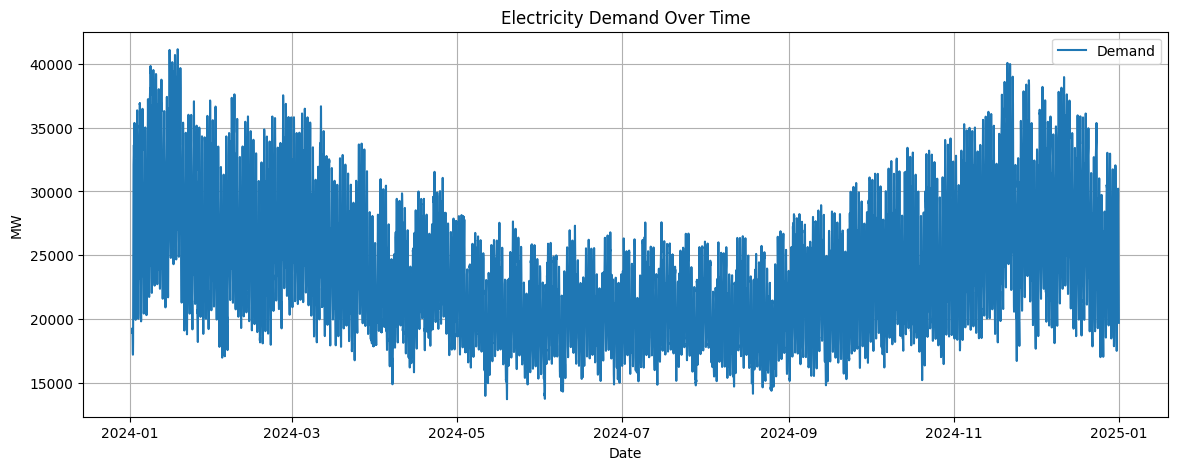

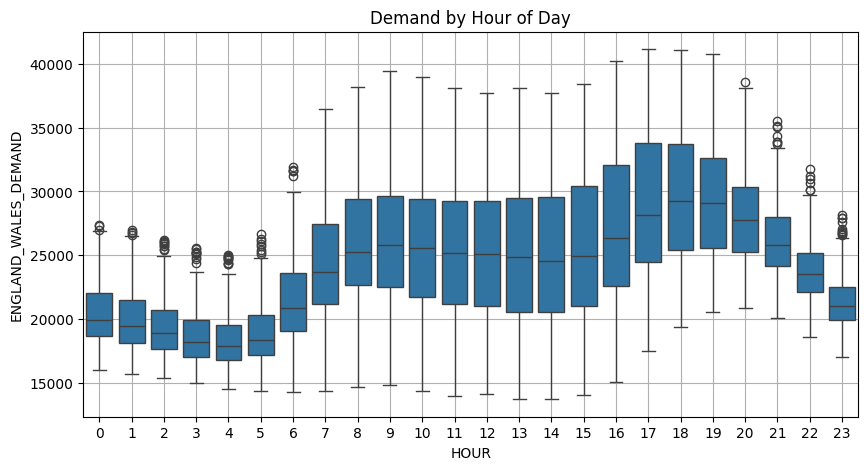

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 5))
plt.plot(df["DATETIME"], df["ENGLAND_WALES_DEMAND"], label="Demand")
plt.title("Electricity Demand Over Time")
plt.xlabel("Date")
plt.ylabel("MW")
plt.grid(True)
plt.legend()
plt.show()

# Hourly pattern
plt.figure(figsize=(10, 5))
sns.boxplot(x="HOUR", y="ENGLAND_WALES_DEMAND", data=df)
plt.title("Demand by Hour of Day")
plt.grid(True)
plt.show()

## 3. 🚨 Anomaly Detection
Z-score method is used to flag outliers in energy demand.

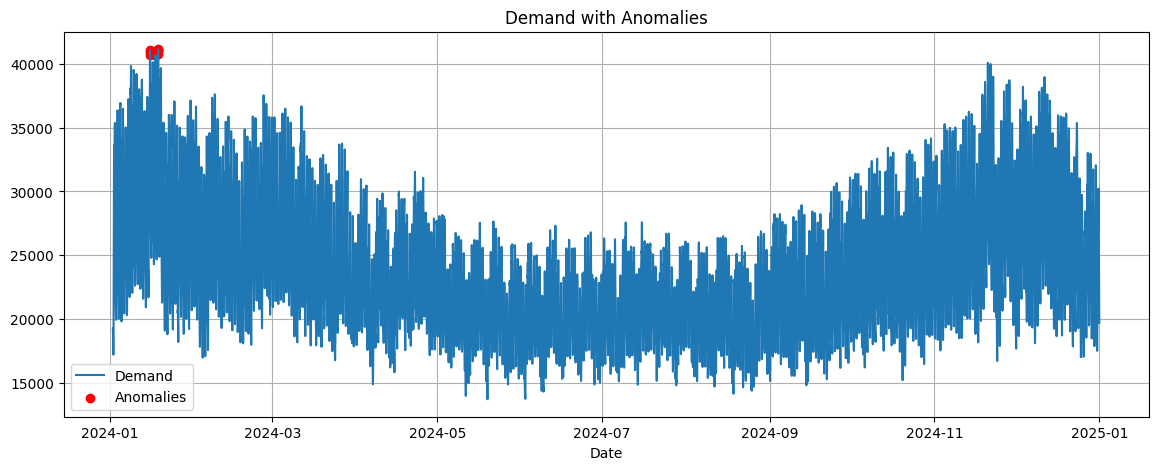

In [13]:
from scipy.stats import zscore
df["Z_SCORE"] = zscore(df["ENGLAND_WALES_DEMAND"])
anomalies = df[df["Z_SCORE"].abs() > 3]

# Visualize anomalies
plt.figure(figsize=(14, 5))
plt.plot(df["DATETIME"], df["ENGLAND_WALES_DEMAND"], label="Demand")
plt.scatter(anomalies["DATETIME"], anomalies["ENGLAND_WALES_DEMAND"], color="red", label="Anomalies")
plt.title("Demand with Anomalies")
plt.xlabel("Date")
plt.legend()
plt.grid(True)
plt.show()

## 4. 🤖 Machine Learning Models
We use Ridge, Lasso, and Random Forest Regressors for forecasting.

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

features = ["HOUR", "WEEKDAY", "MONTH", "LAG_1H", "LAG_1D"]
target = "ENGLAND_WALES_DEMAND"

X_train, X_test, y_train, y_test = train_test_split(df[features], df[target], test_size=0.2, shuffle=False)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

ridge = Ridge().fit(X_train_scaled, y_train)
lasso = Lasso().fit(X_train_scaled, y_train)
rf = RandomForestRegressor(n_estimators=100).fit(X_train, y_train)

def evaluate(model, X, y_true, name):
    y_pred = model.predict(X)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{name}: MAE={mae:.2f}, RMSE={rmse:.2f}")
    return y_pred

ridge_pred = evaluate(ridge, X_test_scaled, y_test, "Ridge")
lasso_pred = evaluate(lasso, X_test_scaled, y_test, "Lasso")
rf_pred = evaluate(rf, X_test, y_test, "Random Forest")

Ridge: MAE=1053.73, RMSE=1336.93
Lasso: MAE=1052.74, RMSE=1336.68
Random Forest: MAE=581.80, RMSE=766.29


## 5. 🧠 LSTM Deep Learning Model
Time-series LSTM to capture temporal demand patterns.

In [15]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

X_lstm = df[["LAG_1H", "LAG_1D"]].values
y_lstm = df["ENGLAND_WALES_DEMAND"].values
X_lstm = X_lstm.reshape((X_lstm.shape[0], X_lstm.shape[1], 1))

X_lstm_train, X_lstm_test = X_lstm[:-500], X_lstm[-500:]
y_lstm_train, y_lstm_test = y_lstm[:-500], y_lstm[-500:]

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(2,1)),
    Dropout(0.2),
    LSTM(64),
    Dropout(0.2),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X_lstm_train, y_lstm_train, validation_data=(X_lstm_test, y_lstm_test), epochs=10, batch_size=32)

lstm_pred = model.predict(X_lstm_test).flatten()
mae = mean_absolute_error(y_lstm_test, lstm_pred)
rmse = np.sqrt(mean_squared_error(y_lstm_test, lstm_pred))
print(f"LSTM: MAE={mae:.2f}, RMSE={rmse:.2f}")

Epoch 1/10


c:\Users\DELL\Documents\UK work\EnergyForecast\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


532/532 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 619633600.0000 - val_loss: 655969600.0000
Epoch 2/10
532/532 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 612981376.0000 - val_loss: 654239104.0000
Epoch 3/10
532/532 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 612107072.0000 - val_loss: 652552064.0000
Epoch 4/10
532/532 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 608566848.0000 - val_loss: 650881920.0000
Epoch 5/10
532/532 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 609206912.0000 - val_loss: 649224320.0000
Epoch 6/10
532/532 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 604120320.0000 - val_loss: 647570816.0000
Epoch 7/10
532/532 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 601357376.0000 - val_loss: 645921856.0000
Epoch 8/10
532/532 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 600262272.0000 - val_loss: 644277120.0000
Epoch 9/10
532/532 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 598182656.0000 - val_loss: 642635648.0000
Epoch 10/10
532/532 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 596592000.0000 - val_loss: 64099

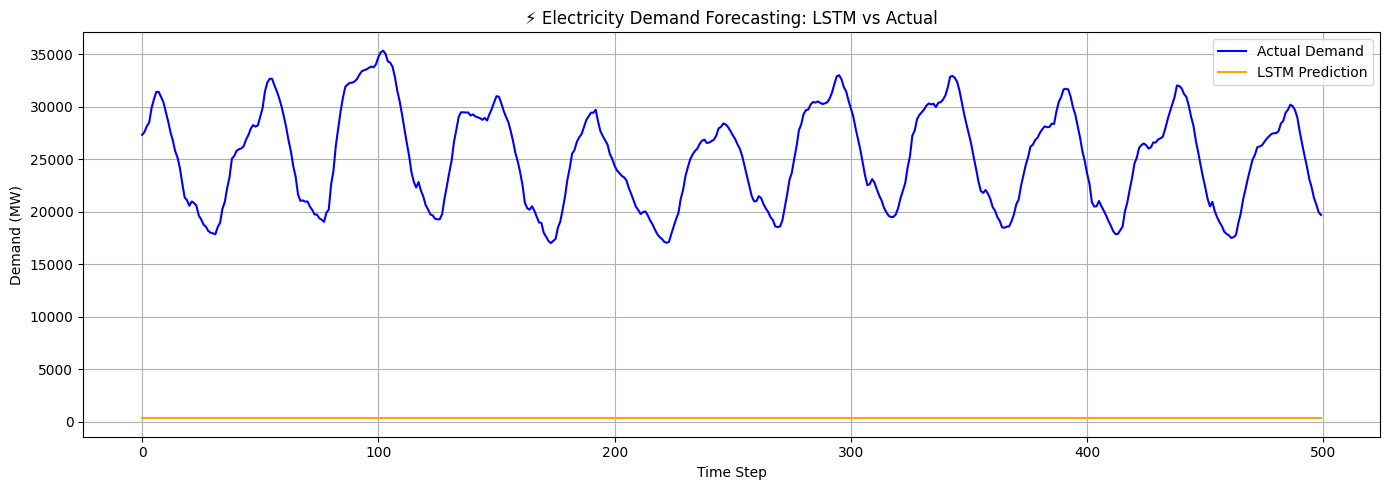

In [16]:
import matplotlib.pyplot as plt

# Plot real vs predicted
plt.figure(figsize=(14, 5))
plt.plot(range(len(y_lstm_test)), y_lstm_test, label="Actual Demand", color="blue")
plt.plot(range(len(lstm_pred)), lstm_pred, label="LSTM Prediction", color="orange")
plt.title("⚡ Electricity Demand Forecasting: LSTM vs Actual")
plt.xlabel("Time Step")
plt.ylabel("Demand (MW)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## 6. ✅ Conclusion & Next Steps
This notebook demonstrated a complete machine learning pipeline for electricity demand forecasting:
- Preprocessing real-world energy data
- EDA for understanding patterns
- Detecting anomalies
- Comparing ML models and LSTM

🎓 Ready for deployment, reporting in Power BI/Tableau, and writing a full thesis!

---

Epoch 1/20


c:\Users\DELL\Documents\UK work\EnergyForecast\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


532/532 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0242 - val_loss: 0.0010
Epoch 2/20
532/532 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0019 - val_loss: 9.3870e-04
Epoch 3/20
532/532 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0016 - val_loss: 8.9989e-04
Epoch 4/20
532/532 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0016 - val_loss: 8.4484e-04
Epoch 5/20
532/532 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0014 - val_loss: 7.8022e-04
Epoch 6/20
532/532 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0013 - val_loss: 0.0012
Epoch 7/20
532/532 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0013 - val_loss: 8.1332e-04
Epoch 8/20
532/532 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0012 - val_loss: 7.4294e-04
Epoch 9/20
532/532 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0012 - val_loss: 7.7559e-04
Epoch 10/20
532/532 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0012 - val_loss: 7.2950e-04
Epoch 11/20
532/532 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0012 - val_loss: 7.6624e-04
Epoch 12/20
532/532 ━━━━━━━

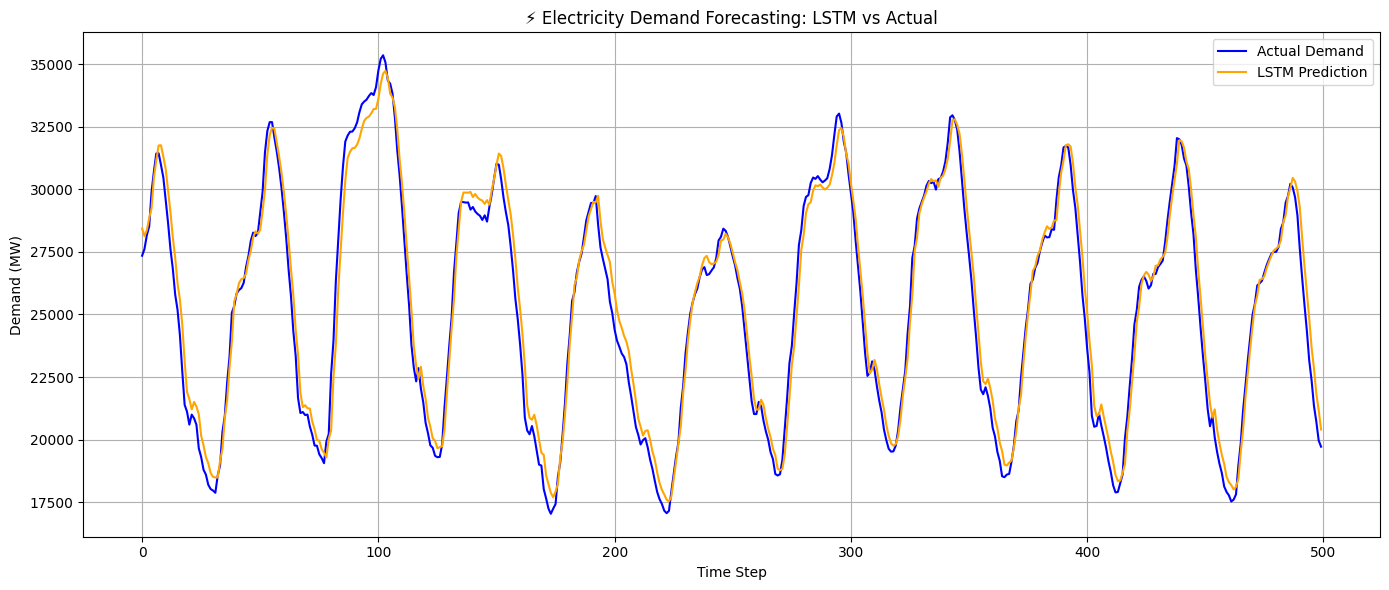

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# === Load Data ===
df = pd.read_csv("C:/Users/DELL/Documents/UK work/EnergyForecast/demanddata_2024.csv")

# === Parse Dates and Sort ===
df['SETTLEMENT_DATE'] = pd.to_datetime(df['SETTLEMENT_DATE'], format='%d-%b-%Y')
df = df.sort_values(by=['SETTLEMENT_DATE', 'SETTLEMENT_PERIOD']).reset_index(drop=True)

# === Select Target ===
target_col = 'ENGLAND_WALES_DEMAND'

# === Feature Engineering: Lag Features ===
df['LAG_1H'] = df[target_col].shift(1)
df['LAG_1D'] = df[target_col].shift(48)
df.dropna(inplace=True)

# === Normalize Features ===
features = ['LAG_1H', 'LAG_1D']
scaler_X = MinMaxScaler()
X_scaled = scaler_X.fit_transform(df[features])

scaler_y = MinMaxScaler()
y_scaled = scaler_y.fit_transform(df[[target_col]])

# === Reshape for LSTM ===
X_lstm = X_scaled.reshape((X_scaled.shape[0], X_scaled.shape[1], 1))
y_lstm = y_scaled

# === Train-Test Split ===
X_train, X_test = X_lstm[:-500], X_lstm[-500:]
y_train, y_test = y_lstm[:-500], y_lstm[-500:]

# === Define LSTM Model ===
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    Dropout(0.2),
    LSTM(64),
    Dropout(0.2),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')

# === Train Model ===
history = model.fit(X_train, y_train, validation_data=(X_test, y_test),
                    epochs=20, batch_size=32, verbose=1)

# === Predict ===
y_pred_scaled = model.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_true = scaler_y.inverse_transform(y_test)

# === Evaluation ===
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
print(f"LSTM Model - MAE: {mae:.2f} MW, RMSE: {rmse:.2f} MW")

# === Visualization ===
plt.figure(figsize=(14, 6))
plt.plot(y_true, label="Actual Demand", color='blue')
plt.plot(y_pred, label="LSTM Prediction", color='orange')
plt.title("⚡ Electricity Demand Forecasting: LSTM vs Actual")
plt.xlabel("Time Step")
plt.ylabel("Demand (MW)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


C:\Users\DELL\AppData\Local\Temp\ipykernel_33900\2598816184.py:77: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


Linear Regression RMSE on Validation: 7.423945547772194e-16
Random Forest RMSE on Validation: 0.007941370782135644
LSTM training data shape: (12283, 10, 57) (12283,)
Epoch 1/50


c:\Users\DELL\Documents\UK work\EnergyForecast\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


192/192 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - loss: 0.0485 - val_loss: 0.0025 - learning_rate: 0.0010
Epoch 2/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - loss: 0.0035 - val_loss: 0.0017 - learning_rate: 0.0010
Epoch 3/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - loss: 0.0023 - val_loss: 0.0017 - learning_rate: 0.0010
Epoch 4/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 0.0017 - val_loss: 0.0018 - learning_rate: 0.0010
Epoch 5/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - loss: 0.0015 - val_loss: 0.0012 - learning_rate: 0.0010
Epoch 6/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 0.0013 - val_loss: 0.0012 - learning_rate: 0.0010
Epoch 7/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - loss: 0.0012 - val_loss: 9.1373e-04 - learning_rate: 0.0010
Epoch 8/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - loss: 0.0011 - val_loss: 9.6267e-04 - learning_rate: 0.0010
Epoch 9/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - loss: 0.0010 - val_loss: 8.8202e-04 - learning_rate: 0.0010


C:\Users\DELL\AppData\Local\Temp\ipykernel_33900\2598816184.py:257: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['anomaly_flag'] = test_anomaly_pred  # Values of -1 indicate anomalies


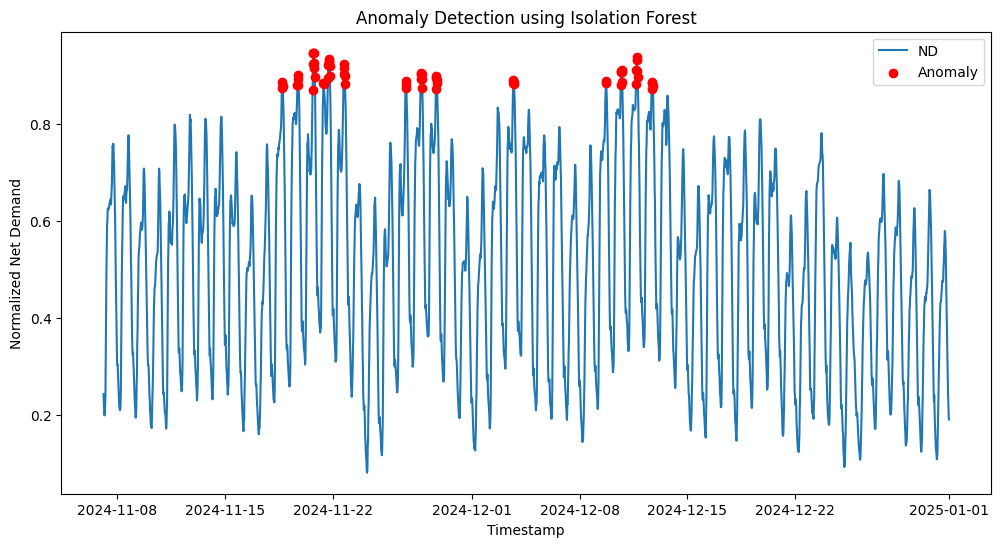

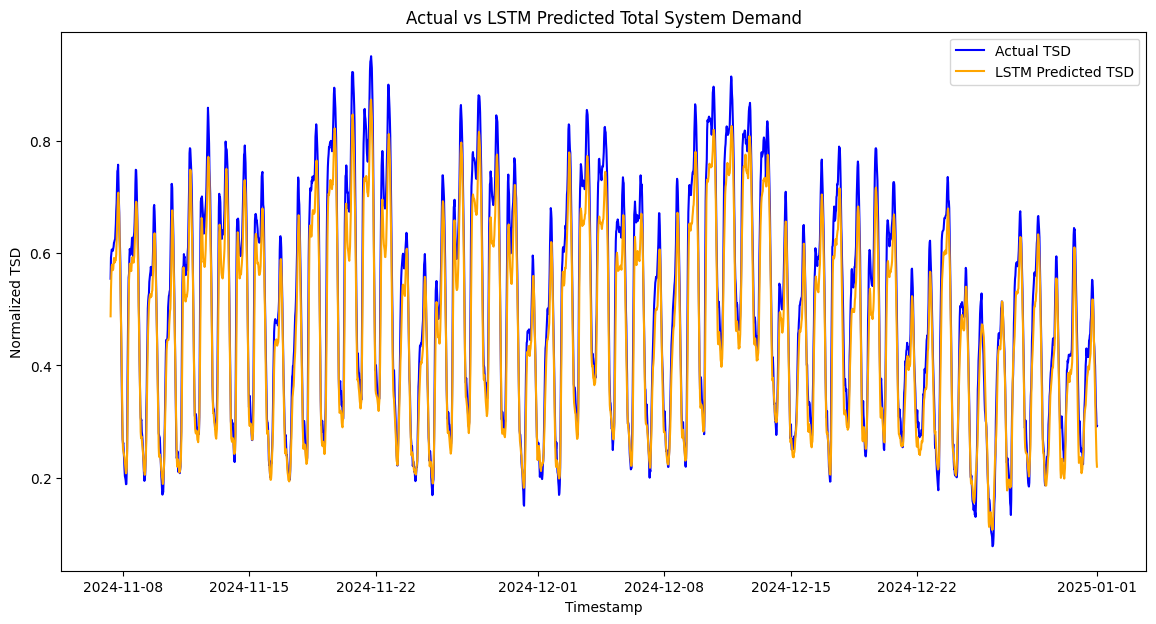

LSTM Evaluation Metrics:
RMSE: 0.051764395583056226
MAE: 0.043564144521951675
MAPE: 0.08553699404001236


'\n# app.py\nimport streamlit as st\nimport pandas as pd\nimport matplotlib.pyplot as plt\nimport joblib  # to load the trained models if saved\n\nst.title("Electricity Demand Forecasting Dashboard")\n\n# Load data and models (this part assumes you have saved your trained model)\n# data = pd.read_csv(\'processed_test_data.csv\', parse_dates=[\'timestamp\'])\n# lstm_model = joblib.load(\'lstm_model.pkl\')  # For TensorFlow, consider saving with model.save()\n\nst.write("This is a prototype dashboard for visualizing electricity demand forecasts and anomalies.")\n\n# Example: Plot test ND with anomaly flags\n# Assume `test` DataFrame is available (in practice, load your saved predictions)\nst.line_chart(data[\'ND\'])\nst.write("Anomalies detected:", len(data[data[\'anomaly_flag\'] == -1]))\n'

In [21]:
# %% [markdown]
# # Electricity Demand Forecasting and Anomaly Detection
# 
# This notebook implements an end-to-end pipeline for energy demand forecasting and anomaly detection following the methodology in the FYP report. The pipeline covers:
# 
# - Data ingestion and cleaning
# - Feature engineering (lag features, rolling statistics, temporal encoding)
# - Construction of multiple models: baseline regression, ensemble (Random Forest), and deep learning using LSTM
# - Anomaly detection using Isolation Forest
# - Evaluation and visualization of results
# 
# Each section below corresponds to parts of the methodology and implementation chapters in the report.

# %% [code]
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

# Machine learning tools
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import KNNImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, IsolationForest
from sklearn.model_selection import GridSearchCV

# Deep learning libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# For reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# %% [markdown]
# ## 3. Data Collection and Preprocessing
# 
# We assume that the data (named **demanddata_2024.csv**) includes columns such as:
# - `SETTLEMENT_DATE` (e.g., YYYY-MM-DD)
# - `SETTLEMENT_PERIOD` (integers 1-48 representing 30-minute intervals)
# - `TSD`: Total demand
# - `ND`: Net demand
# - Other columns such as embedded renewable generation, cross-border flows, etc.
# 
# The following cells load the data, combine the date and period into a continuous timestamp, and then handle missing values and normalize the data.

# %% [code]
# Data Ingestion
df = pd.read_csv('demanddata_2024.csv')  # Adjust the filename/path as needed

# Combine SETTLEMENT_DATE and SETTLEMENT_PERIOD into one datetime index
def create_timestamp(row):
    base_date = pd.to_datetime(row['SETTLEMENT_DATE'])
    # Each settlement period represents a 30-min slot; period 1 means 00:00 - 00:30, so subtract 1 and multiply
    minutes_offset = (row['SETTLEMENT_PERIOD'] - 1) * 30
    return base_date + pd.Timedelta(minutes=minutes_offset)

df['timestamp'] = df.apply(create_timestamp, axis=1)
df.set_index('timestamp', inplace=True)

# Optionally, drop the original date columns
df.drop(columns=['SETTLEMENT_DATE', 'SETTLEMENT_PERIOD'], inplace=True)

# %% [markdown]
# ### Missing Value Handling and Imputation
# 
# First, we use forward-fill for time continuity. Next, for any remaining missing values (e.g., in embedded generation columns), we use K-Nearest Neighbors imputation.

# %% [code]
# Forward-fill missing values to preserve temporal continuity
df.fillna(method='ffill', inplace=True)

# Use KNNImputer as an additional safeguard for remaining missing data
imputer = KNNImputer(n_neighbors=5)
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns, index=df.index)

# %% [markdown]
# ### Normalization
# 
# We normalize all features using Min-Max scaling. This prevents models from being biased toward features with larger magnitudes.

# %% [code]
scaler = MinMaxScaler()
scaled_data = pd.DataFrame(scaler.fit_transform(df_imputed), columns=df_imputed.columns, index=df_imputed.index)

# %% [markdown]
# ## 4. Feature Engineering
# 
# To capture the temporal patterns in energy demand, we add several new features:
# 
# - **Lag Features:** Previous values of TSD and ND (e.g., 1, 2, 3, and 6 time steps ago).
# - **Rolling Statistics:** Rolling mean over a short window.
# - **Temporal Variables:** Hour of day and day of week, one-hot encoded.
# 
# Then, we drop any rows that lose data due to lagging and rolling computations.

# %% [code]
# Create lag features for TSD and ND
lags = [1, 2, 3, 6]
for lag in lags:
    scaled_data[f'TSD_lag_{lag}'] = scaled_data['TSD'].shift(lag)
    scaled_data[f'ND_lag_{lag}'] = scaled_data['ND'].shift(lag)

# Add rolling mean (window of 3 periods for short-term volatility)
scaled_data['TSD_roll_mean_3'] = scaled_data['TSD'].rolling(window=3).mean()

# Extract temporal features from the index
scaled_data['hour'] = scaled_data.index.hour
scaled_data['dayofweek'] = scaled_data.index.dayofweek

# One-hot encode the hour and day-of-week variables
scaled_data = pd.get_dummies(scaled_data, columns=['hour', 'dayofweek'], drop_first=True)

# Drop rows with NaN values that were introduced by shifting/rolling
scaled_data.dropna(inplace=True)

# %% [markdown]
# ## 5. Data Splitting for Time-Series Modeling
# 
# We split the dataset chronologically: 70% training, 15% validation, 15% testing. The target variable is **TSD** (Total System Demand) and the remaining columns (except TSD) form the features.

# %% [code]
# Determine split sizes
train_size = int(len(scaled_data) * 0.7)
val_size = int(len(scaled_data) * 0.15)
test_size = len(scaled_data) - train_size - val_size

train = scaled_data.iloc[:train_size]
val = scaled_data.iloc[train_size:train_size+val_size]
test = scaled_data.iloc[train_size+val_size:]

# Define the target and features; using all other features as predictors
target = 'TSD'
features = [col for col in train.columns if col != target]

X_train = train[features]
y_train = train[target]
X_val = val[features]
y_val = val[target]
X_test = test[features]
y_test = test[target]

# %% [markdown]
# ## 6. Model Development
# 
# We develop three types of models:
# 
# 1. **Baseline Regression Models:** Linear Regression (diagnostic), Ridge, Lasso, Polynomial (if needed), and Support Vector Regression.
# 2. **Ensemble Methods:** Random Forest Regressor (and optionally Gradient Boosting).
# 3. **Deep Learning with LSTM:** Designed to capture long-term dependencies.
# 
# The following cells demonstrate a baseline linear regression and a Random Forest model on the non-sequential data.

# %% [code]
# Baseline: Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_val_pred = lr_model.predict(X_val)
lr_rmse = np.sqrt(mean_squared_error(y_val, lr_val_pred))
print("Linear Regression RMSE on Validation:", lr_rmse)

# %% [code]
# Ensemble: Random Forest Regressor with default hyperparameters
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_val_pred = rf_model.predict(X_val)
rf_rmse = np.sqrt(mean_squared_error(y_val, rf_val_pred))
print("Random Forest RMSE on Validation:", rf_rmse)

# You can similarly implement hyperparameter tuning using GridSearchCV if desired.

# %% [markdown]
# ### 6.1 LSTM Model for Time-Series Forecasting
# 
# The LSTM model requires input data to be three-dimensional: (samples, timesteps, features). Below we define a helper function to reshape the data into sequences using a sliding window. In our example, we use a time window of 10 timesteps. Adjust this parameter as needed.

# %% [code]
def create_sequences(X, y, time_steps=10):
    """
    Create sequences of features and targets for LSTM modeling.
    Each sequence is explicitly cast to np.float32.
    """
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        seq_X = X.iloc[i:(i+time_steps)].values.astype(np.float32)
        seq_y = np.float32(y.iloc[i+time_steps])
        Xs.append(seq_X)
        ys.append(seq_y)
    return np.array(Xs), np.array(ys)

# Create sequential data for train, validation, and test sets
time_steps = 10
X_train_seq, y_train_seq = create_sequences(train[features], train[target], time_steps)
X_val_seq, y_val_seq = create_sequences(val[features], val[target], time_steps)
X_test_seq, y_test_seq = create_sequences(test[features], test[target], time_steps)

print("LSTM training data shape:", X_train_seq.shape, y_train_seq.shape)


# %% [markdown]
# Now, we build the LSTM model. It includes:
# - An LSTM layer with 100 units and tanh activation
# - Dropout for regularization
# - A Dense output layer
# 
# We train the model with early stopping to prevent overfitting.

# %% [code]
# Build the LSTM model
lstm_model = Sequential()
lstm_model.add(LSTM(100, activation='tanh', input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])))
lstm_model.add(Dropout(0.2))
lstm_model.add(Dense(1))
lstm_model.compile(optimizer='adam', loss='mse')

# Define callbacks: early stopping and reduce learning rate on plateau
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)

history = lstm_model.fit(X_train_seq, y_train_seq, 
                         epochs=50, 
                         batch_size=64, 
                         validation_data=(X_val_seq, y_val_seq), 
                         callbacks=[early_stop, lr_scheduler],
                         verbose=1)

# %% [markdown]
# Evaluate the LSTM on the test set.

# %% [code]
lstm_predictions = lstm_model.predict(X_test_seq).flatten()
lstm_rmse = np.sqrt(mean_squared_error(y_test_seq, lstm_predictions))
lstm_mae = mean_absolute_error(y_test_seq, lstm_predictions)
lstm_mape = mean_absolute_percentage_error(y_test_seq, lstm_predictions)
print("LSTM Test RMSE:", lstm_rmse)
print("LSTM Test MAE:", lstm_mae)
print("LSTM Test MAPE:", lstm_mape)

# %% [markdown]
# ## 7. Anomaly Detection
# 
# In parallel to forecasting, an anomaly detection mechanism is implemented using the Isolation Forest algorithm. Here we train the Isolation Forest on the clean training data (using the **ND** column as an example) and then use it to flag anomalies on the test set.
# 
# Note: You may choose to apply anomaly detection to a different variable or use several features if needed.

# %% [code]
# Anomaly detection on the 'ND' (Net Demand) variable
iso_forest = IsolationForest(contamination=0.01, random_state=42)
iso_forest.fit(train[['ND']])
test_anomaly_pred = iso_forest.predict(test[['ND']])
test['anomaly_flag'] = test_anomaly_pred  # Values of -1 indicate anomalies

# Visualize anomalies in ND on the test set
plt.figure(figsize=(12,6))
plt.plot(test.index, test['ND'], label='ND')
anomalies = test[test['anomaly_flag'] == -1]
plt.scatter(anomalies.index, anomalies['ND'], color='red', label='Anomaly', zorder=5)
plt.xlabel("Timestamp")
plt.ylabel("Normalized Net Demand")
plt.title("Anomaly Detection using Isolation Forest")
plt.legend()
plt.show()

# %% [markdown]
# ## 8. Model Evaluation and Visualization
# 
# We compare models using evaluation metrics such as RMSE, MAE, and MAPE. We also visualize the actual versus forecasted values for qualitative evaluation. In the example below, we compare the LSTM forecast with the actual TSD (Total System Demand) in the test period.

# %% [code]
# For comparison, align the test labels and predictions (note that LSTM test sequences start after `time_steps`)
test_index = test.index[time_steps:]

plt.figure(figsize=(14,7))
plt.plot(test_index, y_test_seq, label='Actual TSD', color='blue')
plt.plot(test_index, lstm_predictions, label='LSTM Predicted TSD', color='orange')
plt.xlabel('Timestamp')
plt.ylabel('Normalized TSD')
plt.title('Actual vs LSTM Predicted Total System Demand')
plt.legend()
plt.show()

# Compute evaluation metrics on test set for LSTM
print("LSTM Evaluation Metrics:")
print("RMSE:", lstm_rmse)
print("MAE:", lstm_mae)
print("MAPE:", lstm_mape)

# %% [markdown]
# ## 9. Deployment and Interactive Visualization (Optional)
# 
# Although the deployment in the methodology is planned via a RESTful API and a dashboard interface, you can use Streamlit to quickly prototype an interactive dashboard. Below is a sample code snippet for a simple Streamlit app. To run it, save the code in a file (e.g., `app.py`) and run it with `streamlit run app.py`.

# %% [code, markdown]
'''
# app.py
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import joblib  # to load the trained models if saved

st.title("Electricity Demand Forecasting Dashboard")

# Load data and models (this part assumes you have saved your trained model)
# data = pd.read_csv('processed_test_data.csv', parse_dates=['timestamp'])
# lstm_model = joblib.load('lstm_model.pkl')  # For TensorFlow, consider saving with model.save()

st.write("This is a prototype dashboard for visualizing electricity demand forecasts and anomalies.")

# Example: Plot test ND with anomaly flags
# Assume `test` DataFrame is available (in practice, load your saved predictions)
st.line_chart(data['ND'])
st.write("Anomalies detected:", len(data[data['anomaly_flag'] == -1]))
'''

# %% [markdown]
# ## 10. Summary
# 
# The code above demonstrates the complete pipeline:
# 
# 1. **Data Ingestion & Cleaning:** Combining date and period into a continuous timestamp, handling missing values.
# 2. **Feature Engineering:** Creation of lag features, rolling statistics, and temporal dummy variables.
# 3. **Modeling:** Using baseline regression, ensemble methods, and LSTM for time-series forecasting.
# 4. **Anomaly Detection:** Isolation Forest flags abnormal patterns.
# 5. **Evaluation & Visualization:** Quantitative metrics and plotted forecasts illustrate model performance.
# 
# This code base is designed to be scalable (using Apache Spark/MongoDB in production) and interpretable (using explainability tools outside the scope of this notebook). It aligns with your FYP methodology and results, and you should further tune or extend the code as needed for your final submission.

# End of Notebook


Dataframe head:
  SETTLEMENT_DATE  SETTLEMENT_PERIOD     ND    TSD  ENGLAND_WALES_DEMAND  \
0     01-JAN-2024                  1  21783  23466                 19539   
1     01-JAN-2024                  2  22521  24103                 20286   
2     01-JAN-2024                  3  22194  24754                 20070   
3     01-JAN-2024                  4  21510  24505                 19424   
4     01-JAN-2024                  5  20619  23977                 18674   

   EMBEDDED_WIND_GENERATION  EMBEDDED_WIND_CAPACITY  \
0                      2804                    6488   
1                      2834                    6488   
2                      2868                    6488   
3                      2901                    6488   
4                      2933                    6488   

   EMBEDDED_SOLAR_GENERATION  EMBEDDED_SOLAR_CAPACITY  NON_BM_STOR  ...  \
0                          0                    16793            0  ...   
1                          0                  

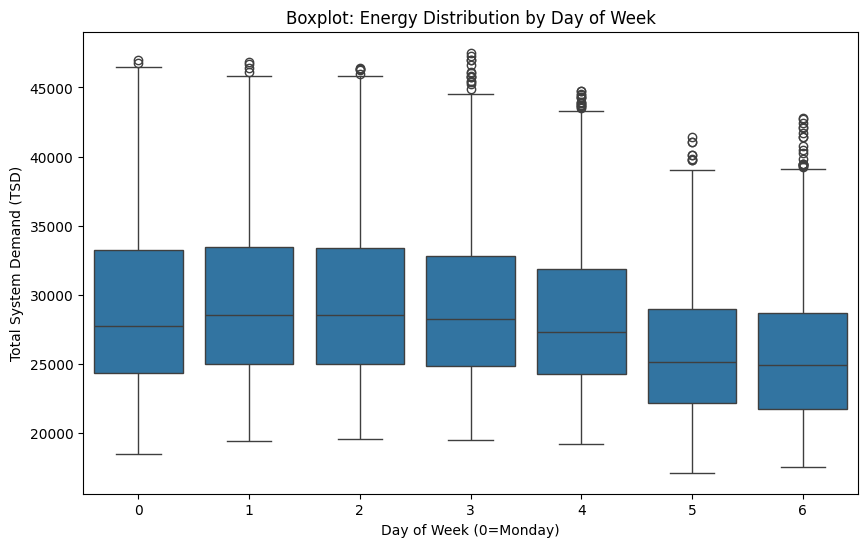

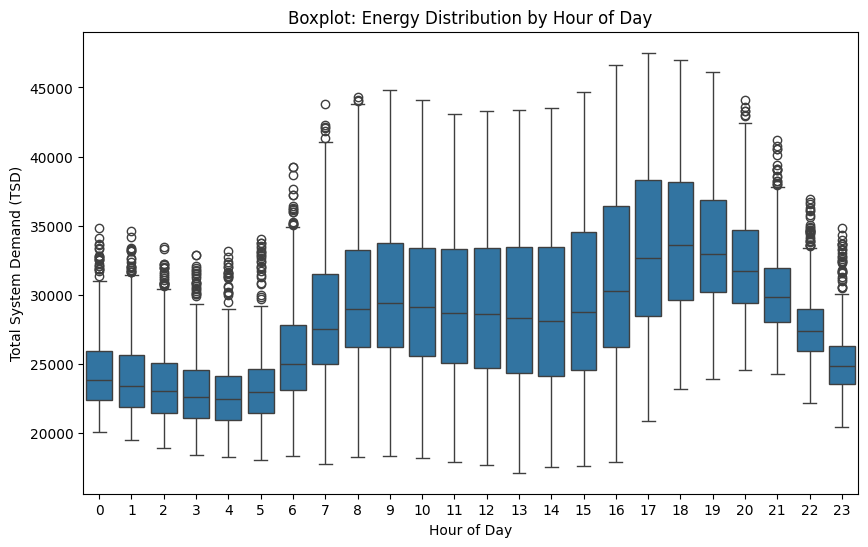

C:\Users\DELL\AppData\Local\Temp\ipykernel_33900\2787333851.py:111: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)



Dataframe after imputation:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 17568 entries, 2024-01-01 00:00:00 to 2024-12-31 23:30:00
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ND                         17568 non-null  float64
 1   TSD                        17568 non-null  float64
 2   ENGLAND_WALES_DEMAND       17568 non-null  float64
 3   EMBEDDED_WIND_GENERATION   17568 non-null  float64
 4   EMBEDDED_WIND_CAPACITY     17568 non-null  float64
 5   EMBEDDED_SOLAR_GENERATION  17568 non-null  float64
 6   EMBEDDED_SOLAR_CAPACITY    17568 non-null  float64
 7   NON_BM_STOR                17568 non-null  float64
 8   PUMP_STORAGE_PUMPING       17568 non-null  float64
 9   SCOTTISH_TRANSFER          17568 non-null  float64
 10  IFA_FLOW                   17568 non-null  float64
 11  IFA2_FLOW                  17568 non-null  float64
 12  BRITNED_FLOW               17568 non-n

c:\Users\DELL\Documents\UK work\EnergyForecast\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


192/192 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - loss: 0.0145 - val_loss: 0.0015 - learning_rate: 0.0010
Epoch 2/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.0023 - val_loss: 0.0011 - learning_rate: 0.0010
Epoch 3/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - loss: 0.0016 - val_loss: 9.9360e-04 - learning_rate: 0.0010
Epoch 4/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - loss: 0.0014 - val_loss: 7.9471e-04 - learning_rate: 0.0010
Epoch 5/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - loss: 0.0012 - val_loss: 7.3593e-04 - learning_rate: 0.0010
Epoch 6/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 0.0011 - val_loss: 0.0011 - learning_rate: 0.0010
Epoch 7/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - loss: 9.1603e-04 - val_loss: 7.2712e-04 - learning_rate: 0.0010
Epoch 8/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 8.0224e-04 - val_loss: 9.3169e-04 - learning_rate: 5.0000e-04
Epoch 9/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 7.8200e-04 - val_loss: 8.5807e

C:\Users\DELL\AppData\Local\Temp\ipykernel_33900\2787333851.py:304: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['anomaly_flag'] = test_anomaly_pred  # -1 indicates an anomaly


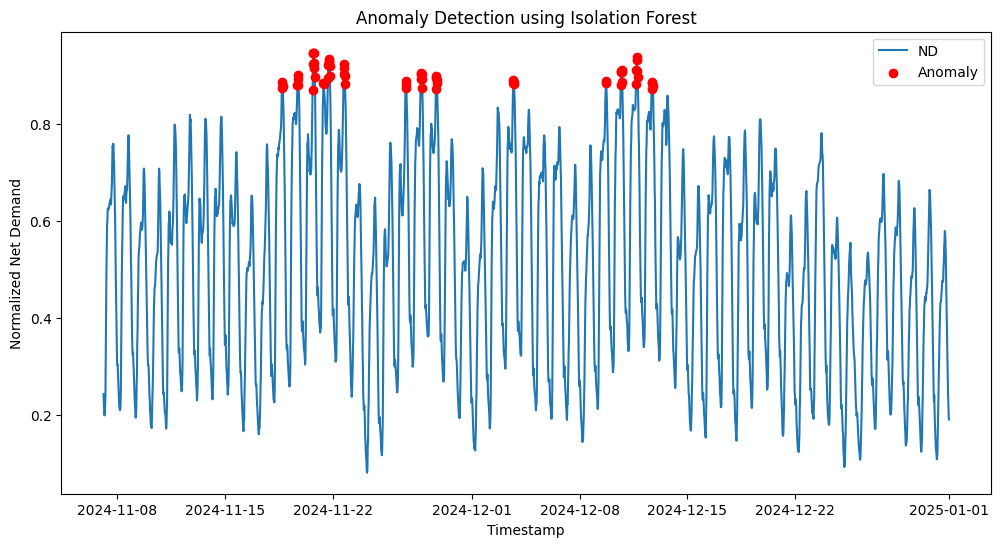

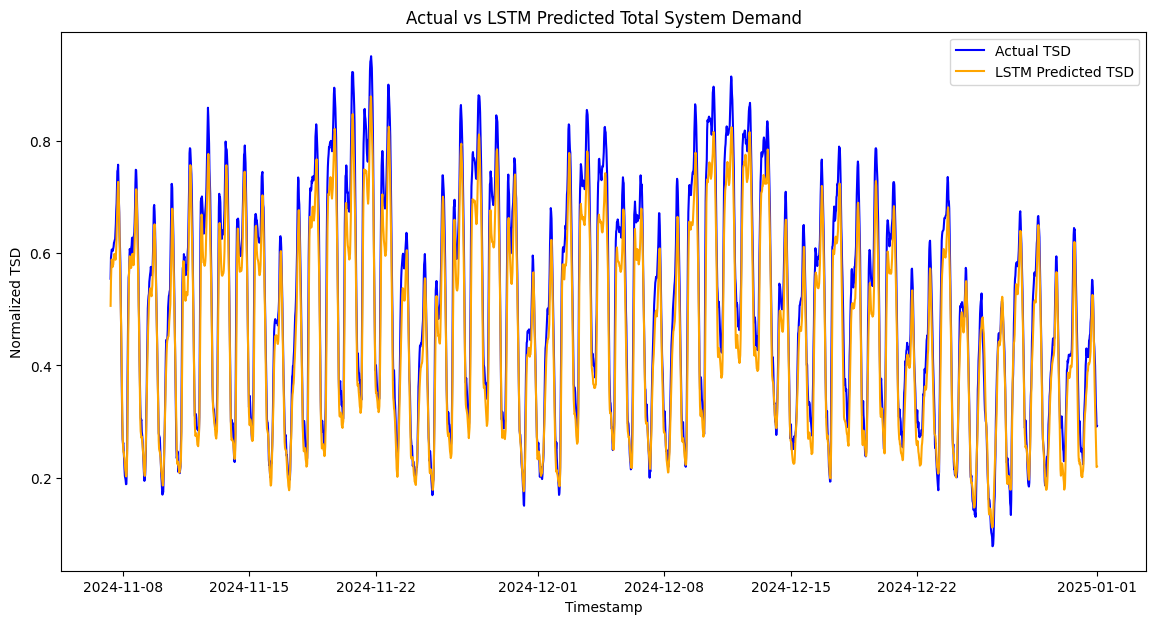

LSTM Evaluation Metrics:
RMSE: 0.05186332662855805
MAE: 0.04425019770860672
MAPE: 0.08815667033195496


'\n# app.py\nimport streamlit as st\nimport pandas as pd\nimport matplotlib.pyplot as plt\nimport joblib  # to load your trained models\n\nst.title("Electricity Demand Forecasting Dashboard")\n\n# For example, load pre-saved test data and predictions\n# data = pd.read_csv(\'processed_test_data.csv\', parse_dates=[\'timestamp\'])\n# lstm_model = joblib.load(\'lstm_model.pkl\')  # Alternatively, use tf.keras.models.load_model()\n\nst.write("Prototype dashboard for visualizing electricity demand forecasts and anomaly detection.")\n\n# Example: Visualize ND with anomaly flags\n# st.line_chart(data[\'ND\'])\n# st.write("Number of anomalies detected: ", len(data[data[\'anomaly_flag\'] == -1]))\n'

In [22]:
# %% [markdown]
# # Electricity Demand Forecasting and Anomaly Detection
# 
# This notebook implements an end-to-end pipeline for energy demand forecasting and anomaly detection following the methodology in the FYP report. The pipeline covers:
# 
# - Data ingestion and cleaning
# - Feature engineering (lag features, rolling statistics, temporal encoding)
# - Construction of multiple models: baseline regression, ensemble (Random Forest), and deep learning using LSTM
# - Anomaly detection using Isolation Forest
# - Evaluation and visualization of results
# 
# Each section below corresponds to parts of the methodology and implementation chapters in the report.

# %% [code]
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

# Machine learning tools
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import KNNImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, IsolationForest
from sklearn.model_selection import GridSearchCV

# Deep learning libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# For reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# %% [markdown]
# ## 3. Data Collection and Preprocessing
# 
# We assume that the data (named **demanddata_2024.csv**) includes columns such as:
# - `SETTLEMENT_DATE` (e.g., YYYY-MM-DD)
# - `SETTLEMENT_PERIOD` (integers 1-48 representing 30-minute intervals)
# - `TSD`: Total System Demand
# - `ND`: Net Demand
# - Other columns such as embedded renewable generation, cross-border flows, etc.
# 
# The following cells load the data, combine the date and period into a continuous timestamp, and then handle missing values and normalize the data.

# %% [code]
# Data Ingestion
df = pd.read_csv('demanddata_2024.csv')  # Adjust the filename/path as needed

# Display basic diagnostic info
print("Dataframe head:")
print(df.head())
print("\nDataframe info:")
print(df.info())

# %% [code, markdown]
# Transform SETTLEMENT_DATE and SETTLEMENT_PERIOD into a datetime index.
def create_timestamp(row):
    base_date = pd.to_datetime(row['SETTLEMENT_DATE'])
    # Each settlement period represents a 30-min slot; period 1 means 00:00 - 00:30
    minutes_offset = (row['SETTLEMENT_PERIOD'] - 1) * 30
    return base_date + pd.Timedelta(minutes=minutes_offset)

df['timestamp'] = df.apply(create_timestamp, axis=1)
df.set_index('timestamp', inplace=True)
df.drop(columns=['SETTLEMENT_DATE', 'SETTLEMENT_PERIOD'], inplace=True)

# %% [markdown]
# ### Visualize the Raw Energy Distribution
# 
# Here, we generate box plots to inspect the distribution of energy demand.
# 
# - **By Day of the Week:** (Assuming a column exists or we create one)
# - **By Hour of the Day:** (Extracted from the timestamp)

# %% [code]
# Add day of week and hour for visualization
df['dayofweek'] = df.index.dayofweek   # Monday=0, Sunday=6
df['hour'] = df.index.hour

# Boxplot for Total System Demand (TSD) by day of week
plt.figure(figsize=(10,6))
sns.boxplot(x='dayofweek', y='TSD', data=df)
plt.title('Boxplot: Energy Distribution by Day of Week')
plt.xlabel('Day of Week (0=Monday)')
plt.ylabel('Total System Demand (TSD)')
plt.show()

# Boxplot for TSD by hour of day
plt.figure(figsize=(10,6))
sns.boxplot(x='hour', y='TSD', data=df)
plt.title('Boxplot: Energy Distribution by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Total System Demand (TSD)')
plt.show()

# %% [markdown]
# ### Missing Value Handling and Imputation
# 
# First, we use forward-fill for time continuity. Next, for any remaining missing values (e.g., in embedded generation columns), we use K-Nearest Neighbors imputation.

# %% [code]
# Forward-fill missing values
df.fillna(method='ffill', inplace=True)

# Apply KNNImputer to ensure all missing values are imputed
imputer = KNNImputer(n_neighbors=5)
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns, index=df.index)

# Print info after imputation
print("\nDataframe after imputation:")
print(df_imputed.info())

# %% [markdown]
# ### Normalization
# 
# Normalize all features using Min-Max scaling. This ensures that features with different magnitudes do not bias the models.

# %% [code]
scaler = MinMaxScaler()
scaled_data = pd.DataFrame(scaler.fit_transform(df_imputed), columns=df_imputed.columns, index=df_imputed.index)

# %% [markdown]
# ## 4. Feature Engineering
# 
# To capture temporal patterns, we create:
# 
# - **Lag Features:** Previous values for TSD and ND (1, 2, 3, and 6 timesteps ago).
# - **Rolling Statistics:** A rolling mean (window of 3 periods).
# - **Temporal Variables:** Hour of day and day of week (one-hot encoded).
# 
# Rows with missing values due to lagging/rolling are dropped.

# %% [code]
# Create lag features for TSD and ND
lags = [1, 2, 3, 6]
for lag in lags:
    scaled_data[f'TSD_lag_{lag}'] = scaled_data['TSD'].shift(lag)
    scaled_data[f'ND_lag_{lag}'] = scaled_data['ND'].shift(lag)

# Rolling mean (window=3)
scaled_data['TSD_roll_mean_3'] = scaled_data['TSD'].rolling(window=3).mean()

# Extract temporal features from the index
scaled_data['hour'] = scaled_data.index.hour
scaled_data['dayofweek'] = scaled_data.index.dayofweek

# One-hot encode hour and dayofweek
scaled_data = pd.get_dummies(scaled_data, columns=['hour', 'dayofweek'], drop_first=True)

# Drop rows with NaN values due to shifting/rolling
scaled_data.dropna(inplace=True)

# Show head of processed data
print("\nProcessed data head:")
print(scaled_data.head())

# %% [markdown]
# ## 5. Data Splitting for Time-Series Modeling
# 
# The dataset is split chronologically into:
# 
# - **Training Set:** 70%
# - **Validation Set:** 15%
# - **Test Set:** 15%
# 
# The target variable is **TSD** (Total System Demand).

# %% [code]
# Split data
train_size = int(len(scaled_data) * 0.7)
val_size = int(len(scaled_data) * 0.15)
test_size = len(scaled_data) - train_size - val_size

train = scaled_data.iloc[:train_size]
val = scaled_data.iloc[train_size:train_size+val_size]
test = scaled_data.iloc[train_size+val_size:]

# Define target and predictors
target = 'TSD'
features = [col for col in train.columns if col != target]

X_train = train[features]
y_train = train[target]
X_val = val[features]
y_val = val[target]
X_test = test[features]
y_test = test[target]

# %% [markdown]
# ## 6. Model Development
# 
# Three modeling approaches are implemented:
# 
# 1. **Baseline Regression Models:** Linear Regression.
# 2. **Ensemble Methods:** Random Forest Regressor.
# 3. **Deep Learning with LSTM:** To capture long-term dependencies.
# 
# The following sections show the baseline and ensemble models on non-sequential data.

# %% [code]
# Baseline: Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_val_pred = lr_model.predict(X_val)
lr_rmse = np.sqrt(mean_squared_error(y_val, lr_val_pred))
print("Linear Regression RMSE on Validation:", lr_rmse)

# %% [code]
# Ensemble: Random Forest Regressor with default hyperparameters
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_val_pred = rf_model.predict(X_val)
rf_rmse = np.sqrt(mean_squared_error(y_val, rf_val_pred))
print("Random Forest RMSE on Validation:", rf_rmse)

# %% [markdown]
# ### 6.1 LSTM Model for Time-Series Forecasting
# 
# The LSTM model requires input data in three dimensions: (samples, timesteps, features). The helper function below creates these sequences.

# %% [code]
def create_sequences(X, y, time_steps=10):
    """
    Create sequences for LSTM. Data is explicitly cast to np.float32.
    """
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        seq_X = X.iloc[i:(i+time_steps)].values.astype(np.float32)
        seq_y = np.float32(y.iloc[i+time_steps])
        Xs.append(seq_X)
        ys.append(seq_y)
    return np.array(Xs), np.array(ys)

# Define time window size
time_steps = 10

# Create sequential data for each set
X_train_seq, y_train_seq = create_sequences(train[features], train[target], time_steps)
X_val_seq, y_val_seq = create_sequences(val[features], val[target], time_steps)
X_test_seq, y_test_seq = create_sequences(test[features], test[target], time_steps)

print("LSTM training data shape:", X_train_seq.shape, y_train_seq.shape)

# %% [markdown]
# Now, build the LSTM model. The architecture includes:
# - An LSTM layer with 100 units and tanh activation
# - A Dropout layer for regularization
# - A Dense output layer
# 
# The model is trained with Early Stopping and a Learning Rate Scheduler.

# %% [code]
# Build LSTM model
lstm_model = Sequential()
lstm_model.add(LSTM(100, activation='tanh', input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])))
lstm_model.add(Dropout(0.2))
lstm_model.add(Dense(1))
lstm_model.compile(optimizer='adam', loss='mse')

# Callbacks for training
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)

# Train the LSTM model
history = lstm_model.fit(
    X_train_seq, y_train_seq, 
    epochs=50, 
    batch_size=64, 
    validation_data=(X_val_seq, y_val_seq), 
    callbacks=[early_stop, lr_scheduler],
    verbose=1
)

# %% [markdown]
# Evaluate LSTM on the test set.

# %% [code]
lstm_predictions = lstm_model.predict(X_test_seq).flatten()
lstm_rmse = np.sqrt(mean_squared_error(y_test_seq, lstm_predictions))
lstm_mae = mean_absolute_error(y_test_seq, lstm_predictions)
lstm_mape = mean_absolute_percentage_error(y_test_seq, lstm_predictions)
print("LSTM Test RMSE:", lstm_rmse)
print("LSTM Test MAE:", lstm_mae)
print("LSTM Test MAPE:", lstm_mape)

# %% [markdown]
# ## 7. Anomaly Detection
# 
# An Isolation Forest is used to flag anomalies. We train it on the **ND** (Net Demand) column from the training data and then predict anomalies on the test set.

# %% [code]
# Train Isolation Forest on ND from training set
iso_forest = IsolationForest(contamination=0.01, random_state=42)
iso_forest.fit(train[['ND']])
test_anomaly_pred = iso_forest.predict(test[['ND']])
test['anomaly_flag'] = test_anomaly_pred  # -1 indicates an anomaly

# Visualize anomalies in ND
plt.figure(figsize=(12,6))
plt.plot(test.index, test['ND'], label='ND')
anomalies = test[test['anomaly_flag'] == -1]
plt.scatter(anomalies.index, anomalies['ND'], color='red', label='Anomaly', zorder=5)
plt.xlabel("Timestamp")
plt.ylabel("Normalized Net Demand")
plt.title("Anomaly Detection using Isolation Forest")
plt.legend()
plt.show()

# %% [markdown]
# ## 8. Model Evaluation and Visualization
# 
# We compare the actual versus the forecasted TSD (Total System Demand) on the test set and compute evaluation metrics.

# %% [code]
# Adjust the test index for the LSTM (accounting for the time_steps offset)
test_index = test.index[time_steps:]

plt.figure(figsize=(14,7))
plt.plot(test_index, y_test_seq, label='Actual TSD', color='blue')
plt.plot(test_index, lstm_predictions, label='LSTM Predicted TSD', color='orange')
plt.xlabel('Timestamp')
plt.ylabel('Normalized TSD')
plt.title('Actual vs LSTM Predicted Total System Demand')
plt.legend()
plt.show()

print("LSTM Evaluation Metrics:")
print("RMSE:", lstm_rmse)
print("MAE:", lstm_mae)
print("MAPE:", lstm_mape)

# %% [markdown]
# ## 9. Deployment and Interactive Visualization (Optional)
# 
# For rapid prototyping, a Streamlit-based dashboard can be used to display predictions and anomaly alerts. Below is a sample code snippet.
# 
# Save the snippet below as `app.py` and run using:
# `streamlit run app.py`

# %% [code, markdown]
'''
# app.py
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import joblib  # to load your trained models

st.title("Electricity Demand Forecasting Dashboard")

# For example, load pre-saved test data and predictions
# data = pd.read_csv('processed_test_data.csv', parse_dates=['timestamp'])
# lstm_model = joblib.load('lstm_model.pkl')  # Alternatively, use tf.keras.models.load_model()

st.write("Prototype dashboard for visualizing electricity demand forecasts and anomaly detection.")

# Example: Visualize ND with anomaly flags
# st.line_chart(data['ND'])
# st.write("Number of anomalies detected: ", len(data[data['anomaly_flag'] == -1]))
'''

# %% [markdown]
# ## 10. Summary
# 
# The notebook demonstrates:
# 
# 1. **Data Ingestion & Cleaning:** Converting date/period into timestamps, handling missing values.
# 2. **Exploratory Visualization:** Using box plots to inspect energy distribution by day and hour.
# 3. **Feature Engineering:** Creating lag features, rolling statistics, and temporal dummy variables.
# 4. **Modeling:** Building baseline (Linear Regression), ensemble (Random Forest), and LSTM models.
# 5. **Anomaly Detection:** Implementing Isolation Forest to flag deviations in Net Demand.
# 6. **Evaluation & Visualization:** Comparing model outputs with actual values and calculating error metrics.
# 
# This implementation aligns with the FYP methodology and results. Adjust and tune sections as needed for your final submission.

# End of Notebook


Spark DataFrame Schema:
root
 |-- SETTLEMENT_DATE: string (nullable = true)
 |-- SETTLEMENT_PERIOD: integer (nullable = true)
 |-- ND: integer (nullable = true)
 |-- TSD: integer (nullable = true)
 |-- ENGLAND_WALES_DEMAND: integer (nullable = true)
 |-- EMBEDDED_WIND_GENERATION: integer (nullable = true)
 |-- EMBEDDED_WIND_CAPACITY: integer (nullable = true)
 |-- EMBEDDED_SOLAR_GENERATION: integer (nullable = true)
 |-- EMBEDDED_SOLAR_CAPACITY: integer (nullable = true)
 |-- NON_BM_STOR: integer (nullable = true)
 |-- PUMP_STORAGE_PUMPING: integer (nullable = true)
 |-- SCOTTISH_TRANSFER: integer (nullable = true)
 |-- IFA_FLOW: integer (nullable = true)
 |-- IFA2_FLOW: integer (nullable = true)
 |-- BRITNED_FLOW: integer (nullable = true)
 |-- MOYLE_FLOW: integer (nullable = true)
 |-- EAST_WEST_FLOW: integer (nullable = true)
 |-- NEMO_FLOW: integer (nullable = true)
 |-- NSL_FLOW: integer (nullable = true)
 |-- ELECLINK_FLOW: integer (nullable = true)
 |-- VIKING_FLOW: integer (nul

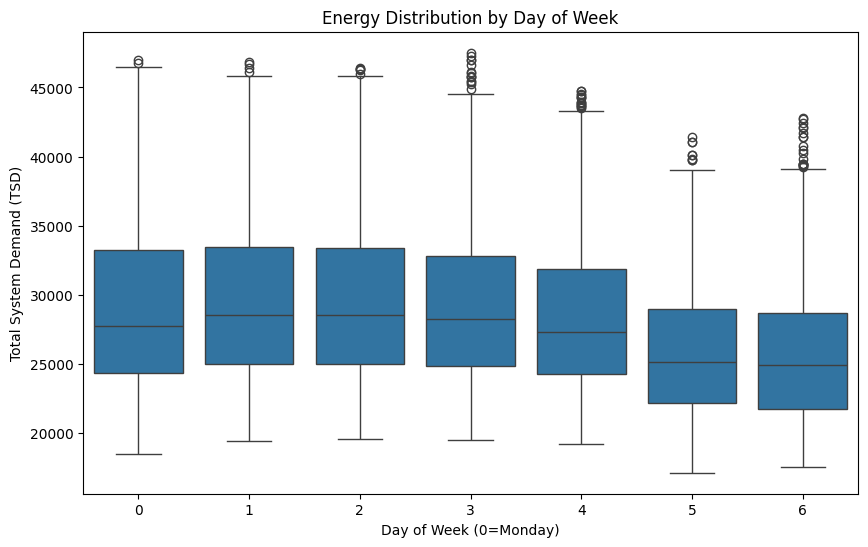

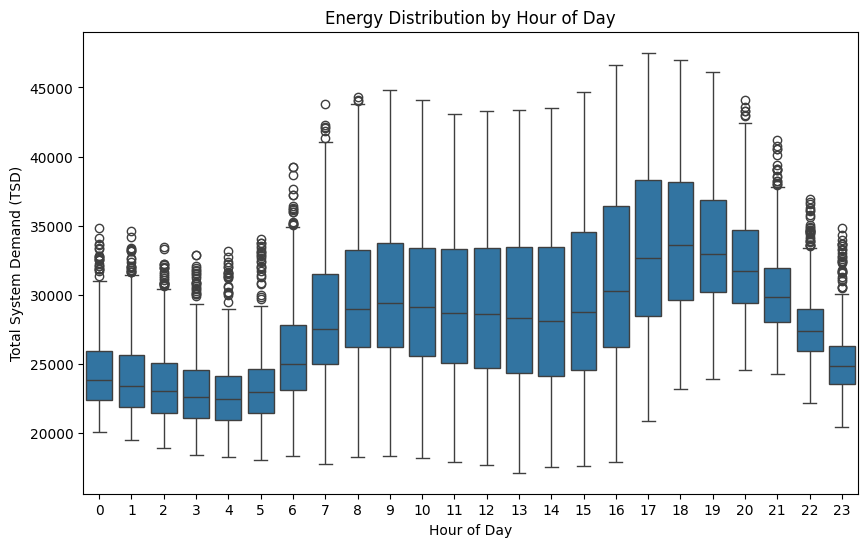

C:\Users\DELL\AppData\Local\Temp\ipykernel_33900\3131734007.py:130: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)



DataFrame after imputation:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 17568 entries, 2024-01-01 00:00:00 to 2024-12-31 23:30:00
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ND                         17568 non-null  float64
 1   TSD                        17568 non-null  float64
 2   ENGLAND_WALES_DEMAND       17568 non-null  float64
 3   EMBEDDED_WIND_GENERATION   17568 non-null  float64
 4   EMBEDDED_WIND_CAPACITY     17568 non-null  float64
 5   EMBEDDED_SOLAR_GENERATION  17568 non-null  float64
 6   EMBEDDED_SOLAR_CAPACITY    17568 non-null  float64
 7   NON_BM_STOR                17568 non-null  float64
 8   PUMP_STORAGE_PUMPING       17568 non-null  float64
 9   SCOTTISH_TRANSFER          17568 non-null  float64
 10  IFA_FLOW                   17568 non-null  float64
 11  IFA2_FLOW                  17568 non-null  float64
 12  BRITNED_FLOW               17568 non-n

C:\Users\DELL\AppData\Local\Temp\ipykernel_33900\3131734007.py:327: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances_rf[indices_rf], y=features_rf[indices_rf], palette="viridis")


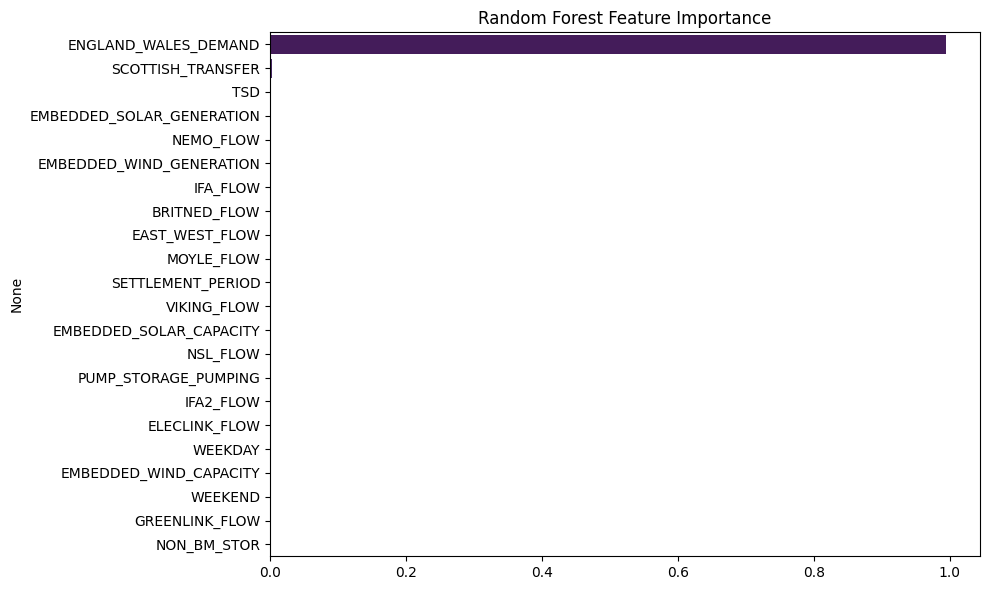


🌱 Gradient Boosting Performance:
RMSE: 130.7668
R² Score: 0.9995


C:\Users\DELL\AppData\Local\Temp\ipykernel_33900\3131734007.py:357: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances_gbm[indices_gbm], y=features_gbm[indices_gbm], palette="magma")


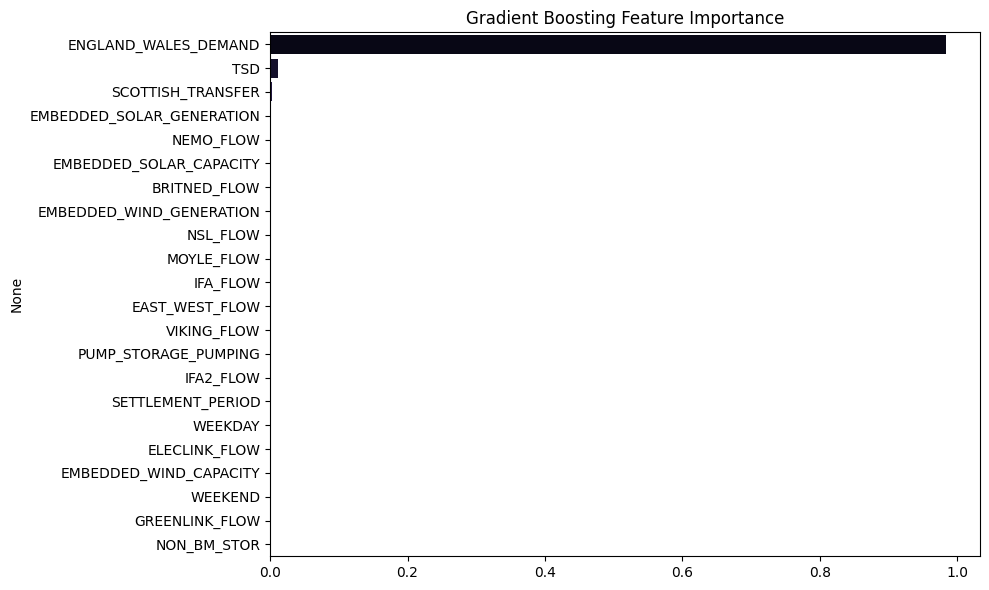

LSTM training data shape: (12283, 10, 57) (12283,)
Epoch 1/50


c:\Users\DELL\Documents\UK work\EnergyForecast\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0437 - val_loss: 0.0023 - learning_rate: 0.0010
Epoch 2/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0034 - val_loss: 0.0021 - learning_rate: 0.0010
Epoch 3/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0022 - val_loss: 0.0012 - learning_rate: 0.0010
Epoch 4/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0017 - val_loss: 0.0013 - learning_rate: 0.0010
Epoch 5/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0015 - val_loss: 0.0011 - learning_rate: 0.0010
Epoch 6/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0013 - val_loss: 9.5964e-04 - learning_rate: 0.0010
Epoch 7/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0011 - val_loss: 7.0965e-04 - learning_rate: 0.0010
Epoch 8/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0011 - val_loss: 9.8983e-04 - learning_rate: 0.0010
Epoch 9/50
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 9.5891e-04 - val_loss: 7.9471e-04 - learning_rate: 0.0010
E

C:\Users\DELL\AppData\Local\Temp\ipykernel_33900\3131734007.py:445: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['anomaly_flag'] = test_anomaly_pred  # -1 indicates anomalies


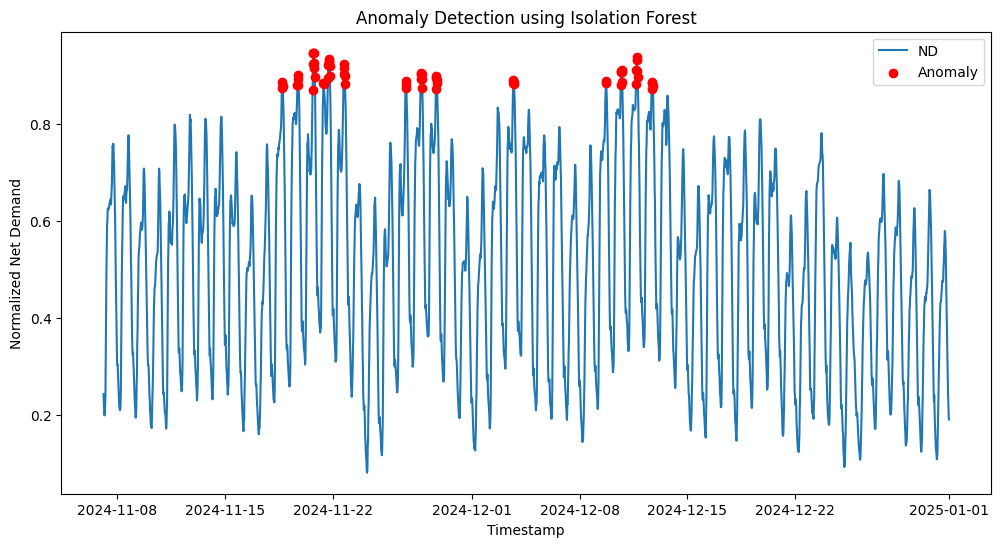

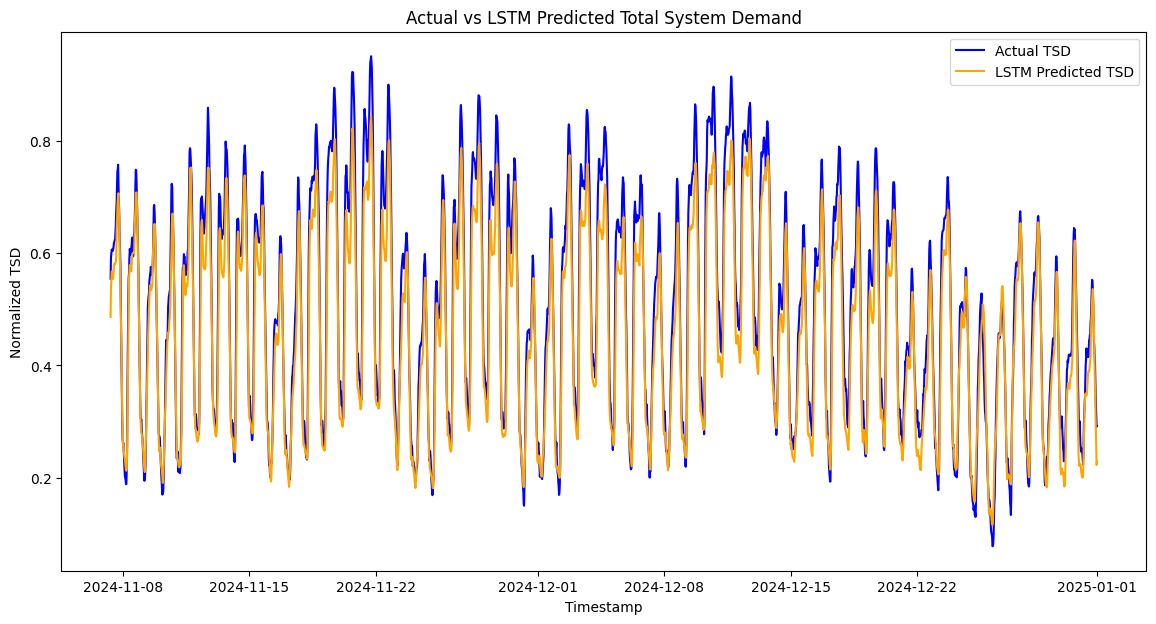

LSTM Evaluation Metrics:
RMSE: 0.05735599995043461
MAE: 0.04730015993118286
MAPE: 0.09348280727863312
TSD    23466
ND     21783
Name: 0, dtype: object
TSD    24103
ND     22521
Name: 1, dtype: object
TSD    24754
ND     22194
Name: 2, dtype: object
TSD    24505
ND     21510
Name: 3, dtype: object
TSD    23977
ND     20619
Name: 4, dtype: object


'\n# app.py\nimport streamlit as st\nimport pandas as pd\nimport matplotlib.pyplot as plt\nimport joblib  # to load your trained models if saved\n\nst.title("Electricity Demand Forecasting Dashboard")\n\n# Load data and pre-trained models (example)\n# data = pd.read_csv(\'processed_test_data.csv\', parse_dates=[\'timestamp\'])\n# lstm_model = joblib.load(\'lstm_model.pkl\')  # Alternatively, use tf.keras.models.load_model()\n\nst.write("Prototype dashboard for visualizing electricity demand forecasts and anomaly detection.")\n\n# Example: Plot ND with anomaly flags (assuming data is available)\n# st.line_chart(data[\'ND\'])\n# st.write("Anomalies detected:", len(data[data[\'anomaly_flag\'] == -1]))\n'

In [41]:

# Import libraries for data processing and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import time


# Spark integration
try:
    from pyspark.sql import SparkSession
except ImportError:
    print("PySpark is not installed. To run the Spark code, please install pyspark: pip install pyspark")

# Create or get existing Spark session
spark = SparkSession.builder \
    .appName("ElectricityDemandForecasting") \
    .getOrCreate()

# Read CSV data into a Spark DataFrame (simulate reading large-scale data)
spark_df = spark.read.csv("demanddata_2024.csv", header=True, inferSchema=True)
print("Spark DataFrame Schema:")
spark_df.printSchema()

# Convert to Pandas DataFrame for further processing in this notebook.
df = spark_df.toPandas()


#  Data Ingestion and Preprocessing

# The historic dataset is downloaded from [NESO Energy Data Portal](https://www.neso.energy/data-portal/historic-demand-data). This section processes the CSV file by converting the date and period columns into a continuous timestamp and performing missing value imputation.


# Data Ingestion from file (already loaded from Spark conversion above)
print("Raw DataFrame Head:")
print(df.head())
print("\nRaw DataFrame Info:")
print(df.info())


# Transform SETTLEMENT_DATE and SETTLEMENT_PERIOD into a datetime index.
def create_timestamp(row):
    base_date = pd.to_datetime(row['SETTLEMENT_DATE'])
    # Each settlement period represents a 30-min slot; period 1 corresponds to 00:00-00:30.
    minutes_offset = (row['SETTLEMENT_PERIOD'] - 1) * 30
    return base_date + pd.Timedelta(minutes=minutes_offset)

df['timestamp'] = df.apply(create_timestamp, axis=1)
df.set_index('timestamp', inplace=True)
df.drop(columns=['SETTLEMENT_DATE', 'SETTLEMENT_PERIOD'], inplace=True)


# Exploratory Visualizations on Raw Data

# Generate boxplots to inspect energy distribution (TSD) by day of the week and by hour of the day.


# Add day of week and hour columns for visualization
df['dayofweek'] = df.index.dayofweek   # Monday=0, Sunday=6
df['hour'] = df.index.hour

# Boxplot for Total System Demand (TSD) by Day of Week
plt.figure(figsize=(10,6))
sns.boxplot(x='dayofweek', y='TSD', data=df)
plt.title('Energy Distribution by Day of Week')
plt.xlabel('Day of Week (0=Monday)')
plt.ylabel('Total System Demand (TSD)')
plt.show()

# Boxplot for TSD by Hour of Day
plt.figure(figsize=(10,6))
sns.boxplot(x='hour', y='TSD', data=df)
plt.title('Energy Distribution by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Total System Demand (TSD)')
plt.show()


# Missing Value Handling and Imputation

# We forward-fill to maintain temporal continuity and then apply a K-Nearest Neighbors imputer.


df.fillna(method='ffill', inplace=True)
from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors=5)
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns, index=df.index)

print("\nDataFrame after imputation:")
print(df_imputed.info())


# Normalization

# All features are scaled using Min-Max scaling.


from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaled_data = pd.DataFrame(scaler.fit_transform(df_imputed), columns=df_imputed.columns, index=df_imputed.index)


# Feature Engineering
# 
# We create additional features:
# 
# - Lag Features: Past values for TSD and ND at various lags.
# - Rolling Mean: A rolling average of TSD to capture local trends.
# - Temporal Variables: Hour and day of week are added and one-hot encoded.
# 
# Rows with insufficient data for these calculations are dropped.

# Create lag features for TSD and ND
lags = [1, 2, 3, 6]
for lag in lags:
    scaled_data[f'TSD_lag_{lag}'] = scaled_data['TSD'].shift(lag)
    scaled_data[f'ND_lag_{lag}'] = scaled_data['ND'].shift(lag)

# Calculate rolling mean (window of 3)
scaled_data['TSD_roll_mean_3'] = scaled_data['TSD'].rolling(window=3).mean()

# Extract hour and day-of-week from index
scaled_data['hour'] = scaled_data.index.hour
scaled_data['dayofweek'] = scaled_data.index.dayofweek

# One-hot encode 'hour' and 'dayofweek'
scaled_data = pd.get_dummies(scaled_data, columns=['hour', 'dayofweek'], drop_first=True)

# Drop rows with NaN values due to lag/rolling features
scaled_data.dropna(inplace=True)
print("\nProcessed Data Head:")
print(scaled_data.head())


#  Data Splitting for Time-Series Modeling
# 
# The dataset is split chronologically:
# - Training: 70%
# - Validation: 15%
# - Test: 15%
# 
# Target variable: TSD (Total System Demand)



train_size = int(len(scaled_data) * 0.7)
val_size = int(len(scaled_data) * 0.15)
test_size = len(scaled_data) - train_size - val_size

train = scaled_data.iloc[:train_size]
val = scaled_data.iloc[train_size:train_size+val_size]
test = scaled_data.iloc[train_size+val_size:]

target = 'TSD'
features = [col for col in train.columns if col != target]

X_train = train[features]
y_train = train[target]
X_val = val[features]
y_val = val[target]
X_test = test[features]
y_test = test[target]


# Model Development
# 
# Three types of models are developed:
# 
# 1. Baseline Regression:** Linear Regression.
# 2. Ensemble Method:** Random Forest Regressor.
# 3. Deep Learning:** LSTM for time-series forecasting.
# 
# The following sections demonstrate baseline regression and Random Forest first, followed by the LSTM model.

# Baseline: Linear Regression
from sklearn.linear_model import LinearRegression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_val_pred = lr_model.predict(X_val)
from sklearn.metrics import mean_squared_error
lr_rmse = np.sqrt(mean_squared_error(y_val, lr_val_pred))
print("Linear Regression RMSE (Validation):", lr_rmse)

from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline

# Evaluation metric
from sklearn.metrics import mean_squared_error

# --------- Ridge Regression ----------
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)
ridge_val_pred = ridge_model.predict(X_val)
ridge_rmse = np.sqrt(mean_squared_error(y_val, ridge_val_pred))
print("Ridge Regression RMSE (Validation):", ridge_rmse)

# --------- Lasso Regression ----------
lasso_model = Lasso(alpha=0.01)
lasso_model.fit(X_train, y_train)
lasso_val_pred = lasso_model.predict(X_val)
lasso_rmse = np.sqrt(mean_squared_error(y_val, lasso_val_pred))
print("Lasso Regression RMSE (Validation):", lasso_rmse)

# --------- Polynomial Regression (degree=2) ----------
poly_model = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
poly_model.fit(X_train, y_train)
poly_val_pred = poly_model.predict(X_val)
poly_rmse = np.sqrt(mean_squared_error(y_val, poly_val_pred))
print("Polynomial Regression (degree=2) RMSE (Validation):", poly_rmse)

# --------- Support Vector Regression (SVR with RBF kernel) ----------
svr_model = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=.1)
svr_model.fit(X_train, y_train)
svr_val_pred = svr_model.predict(X_val)
svr_rmse = np.sqrt(mean_squared_error(y_val, svr_val_pred))
print("SVR (RBF kernel) RMSE (Validation):", svr_rmse)







# Ensemble: Random Forest Regressor
# from sklearn.ensemble import RandomForestRegressor
# rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
# rf_model.fit(X_train, y_train)
# rf_val_pred = rf_model.predict(X_val)
# rf_rmse = np.sqrt(mean_squared_error(y_val, rf_val_pred))
# print("Random Forest RMSE (Validation):", rf_rmse)


from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Split the data (if not done already)
from sklearn.model_selection import train_test_split

df = pd.read_csv("demanddata_2024.csv")
df['SETTLEMENT_DATE'] = pd.to_datetime(df['SETTLEMENT_DATE'], format='%d-%b-%Y')
df['WEEKDAY'] = df['SETTLEMENT_DATE'].dt.dayofweek
df['WEEKEND'] = df['WEEKDAY'].apply(lambda x: 1 if x >= 5 else 0)

X = df.drop(columns=['ND', 'SETTLEMENT_DATE'])
y = df['ND']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ---------------- Random Forest Regressor ---------------- #
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
}

rf_model = RandomForestRegressor(random_state=42)
rf_grid = GridSearchCV(rf_model, rf_params, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_
y_pred_rf = best_rf.predict(X_test)

print("🔍 Random Forest Performance:")
print(f"RMSE: {mean_squared_error(y_test, y_pred_rf) ** 0.5:.4f}")
print(f"R² Score: {r2_score(y_test, y_pred_rf):.4f}")

# Feature Importance Plot for Random Forest
importances_rf = best_rf.feature_importances_
indices_rf = np.argsort(importances_rf)[::-1]
features_rf = X.columns

plt.figure(figsize=(10, 6))
sns.barplot(x=importances_rf[indices_rf], y=features_rf[indices_rf], palette="viridis")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()

# ---------------- Gradient Boosting Regressor ---------------- #
gbm_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'min_samples_split': [2, 5],
}

gbm_model = GradientBoostingRegressor(random_state=42)
gbm_grid = GridSearchCV(gbm_model, gbm_params, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
gbm_grid.fit(X_train, y_train)

best_gbm = gbm_grid.best_estimator_
y_pred_gbm = best_gbm.predict(X_test)

print("\n🌱 Gradient Boosting Performance:")
print(f"RMSE: {mean_squared_error(y_test, y_pred_gbm) ** 0.5:.4f}")
print(f"R² Score: {r2_score(y_test, y_pred_gbm):.4f}")

# Feature Importance Plot for GBM
importances_gbm = best_gbm.feature_importances_
indices_gbm = np.argsort(importances_gbm)[::-1]
features_gbm = X.columns

plt.figure(figsize=(10, 6))
sns.barplot(x=importances_gbm[indices_gbm], y=features_gbm[indices_gbm], palette="magma")
plt.title("Gradient Boosting Feature Importance")
plt.tight_layout()
plt.show()











#  LSTM Model for Time-Series Forecasting

# LSTM requires sequential data in three dimensions (samples, timesteps, features). We define a helper function to create these sequences.

def create_sequences(X, y, time_steps=10):
    """
    Create sequences for LSTM modeling.
    Data is cast to np.float32.
    """
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        seq_X = X.iloc[i:(i+time_steps)].values.astype(np.float32)
        seq_y = np.float32(y.iloc[i+time_steps])
        Xs.append(seq_X)
        ys.append(seq_y)
    return np.array(Xs), np.array(ys)

time_steps = 10
X_train_seq, y_train_seq = create_sequences(train[features], train[target], time_steps)
X_val_seq, y_val_seq = create_sequences(val[features], val[target], time_steps)
X_test_seq, y_test_seq = create_sequences(test[features], test[target], time_steps)
print("LSTM training data shape:", X_train_seq.shape, y_train_seq.shape)


# Build and train the LSTM model using Early Stopping and a Learning Rate Scheduler.

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

lstm_model = Sequential()
lstm_model.add(LSTM(100, activation='tanh', input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])))
lstm_model.add(Dropout(0.2))
lstm_model.add(Dense(1))
lstm_model.compile(optimizer='adam', loss='mse')

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)

history = lstm_model.fit(
    X_train_seq, y_train_seq, 
    epochs=50, 
    batch_size=64, 
    validation_data=(X_val_seq, y_val_seq), 
    callbacks=[early_stop, lr_scheduler],
    verbose=1
)

# Evaluate the LSTM model on the test set.

lstm_predictions = lstm_model.predict(X_test_seq).flatten()
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
lstm_rmse = np.sqrt(mean_squared_error(y_test_seq, lstm_predictions))
lstm_mae = mean_absolute_error(y_test_seq, lstm_predictions)
lstm_mape = mean_absolute_percentage_error(y_test_seq, lstm_predictions)
print("LSTM Test RMSE:", lstm_rmse)
print("LSTM Test MAE:", lstm_mae)
print("LSTM Test MAPE:", lstm_mape)

# Anomaly Detection

# We use an Isolation Forest to identify anomalies in the Net Demand (ND) column.


from sklearn.ensemble import IsolationForest
iso_forest = IsolationForest(contamination=0.01, random_state=42)
iso_forest.fit(train[['ND']])
test_anomaly_pred = iso_forest.predict(test[['ND']])
test['anomaly_flag'] = test_anomaly_pred  # -1 indicates anomalies

plt.figure(figsize=(12,6))
plt.plot(test.index, test['ND'], label='ND')
anomalies = test[test['anomaly_flag'] == -1]
plt.scatter(anomalies.index, anomalies['ND'], color='red', label='Anomaly', zorder=5)
plt.xlabel("Timestamp")
plt.ylabel("Normalized Net Demand")
plt.title("Anomaly Detection using Isolation Forest")
plt.legend()
plt.show()


#  Model Evaluation and Visualization
# We compare actual versus forecasted TSD values on the test set.

# Adjust test index for LSTM sequences (accounting for time_steps offset)
test_index = test.index[time_steps:]
plt.figure(figsize=(14,7))
plt.plot(test_index, y_test_seq, label='Actual TSD', color='blue')
plt.plot(test_index, lstm_predictions, label='LSTM Predicted TSD', color='orange')
plt.xlabel('Timestamp')
plt.ylabel('Normalized TSD')
plt.title('Actual vs LSTM Predicted Total System Demand')
plt.legend()
plt.show()

print("LSTM Evaluation Metrics:")
print("RMSE:", lstm_rmse)
print("MAE:", lstm_mae)
print("MAPE:", lstm_mape)

# %% [markdown]
# ## 7. Simulated Real-Time (IoT) Data Ingestion
# 
# Although the project did not use actual IoT devices, we simulate real-time data ingestion.
# Here, a generator function produces new data rows from the historic dataset, mimicking an IoT stream.
# In production, this data could be ingested via Spark Streaming or an MQTT broker.

# %% [code]
def simulate_iot_stream(data, delay=1):
    """
    Simulate a real-time data stream from historical data.
    Yields one row at a time with a time delay.
    """
    for index, row in data.iterrows():
        yield row
        time.sleep(delay)  # simulate delay in real-time (in seconds)

# Example: Simulate streaming the first 5 rows from the dataset
iot_stream = simulate_iot_stream(df.head(5), delay=0.5)
for data_point in iot_stream:
    print(data_point[['TSD', 'ND']])
    
# %% [markdown]
# ## 8. Deployment and Interactive Visualization (Optional)
# 
# A sample Streamlit dashboard code snippet is provided (as a Python multi-line string) to illustrate how one might deploy the model in production.
# Save this snippet as `app.py` and run it using:
# `streamlit run app.py`

# %% [code, markdown]
'''
# app.py
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import joblib  # to load your trained models if saved

st.title("Electricity Demand Forecasting Dashboard")

# Load data and pre-trained models (example)
# data = pd.read_csv('processed_test_data.csv', parse_dates=['timestamp'])
# lstm_model = joblib.load('lstm_model.pkl')  # Alternatively, use tf.keras.models.load_model()

st.write("Prototype dashboard for visualizing electricity demand forecasts and anomaly detection.")

# Example: Plot ND with anomaly flags (assuming data is available)
# st.line_chart(data['ND'])
# st.write("Anomalies detected:", len(data[data['anomaly_flag'] == -1]))
'''


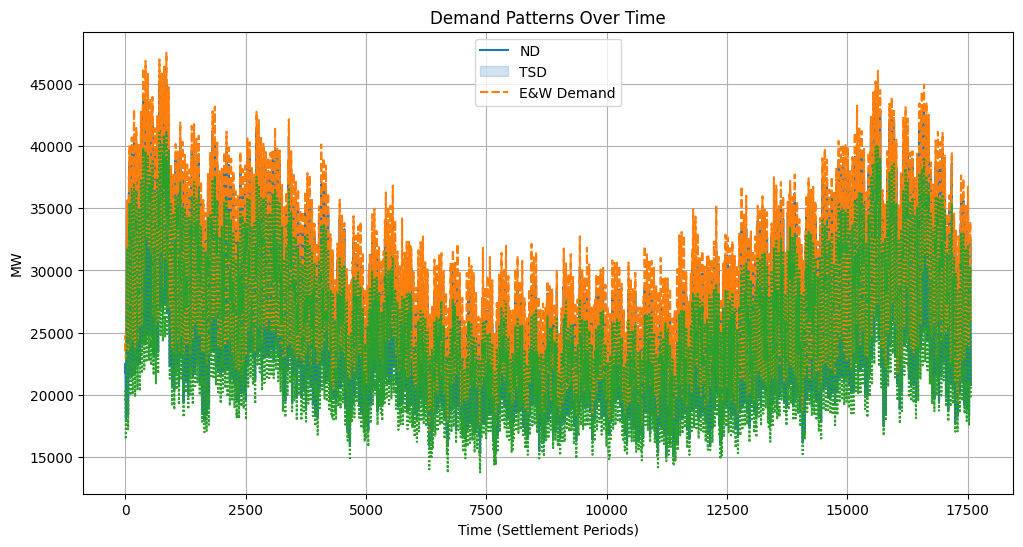

C:\Users\DELL\AppData\Local\Temp\ipykernel_33900\4144639611.py:30: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\Users\DELL\Documents\UK work\EnergyForecast\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


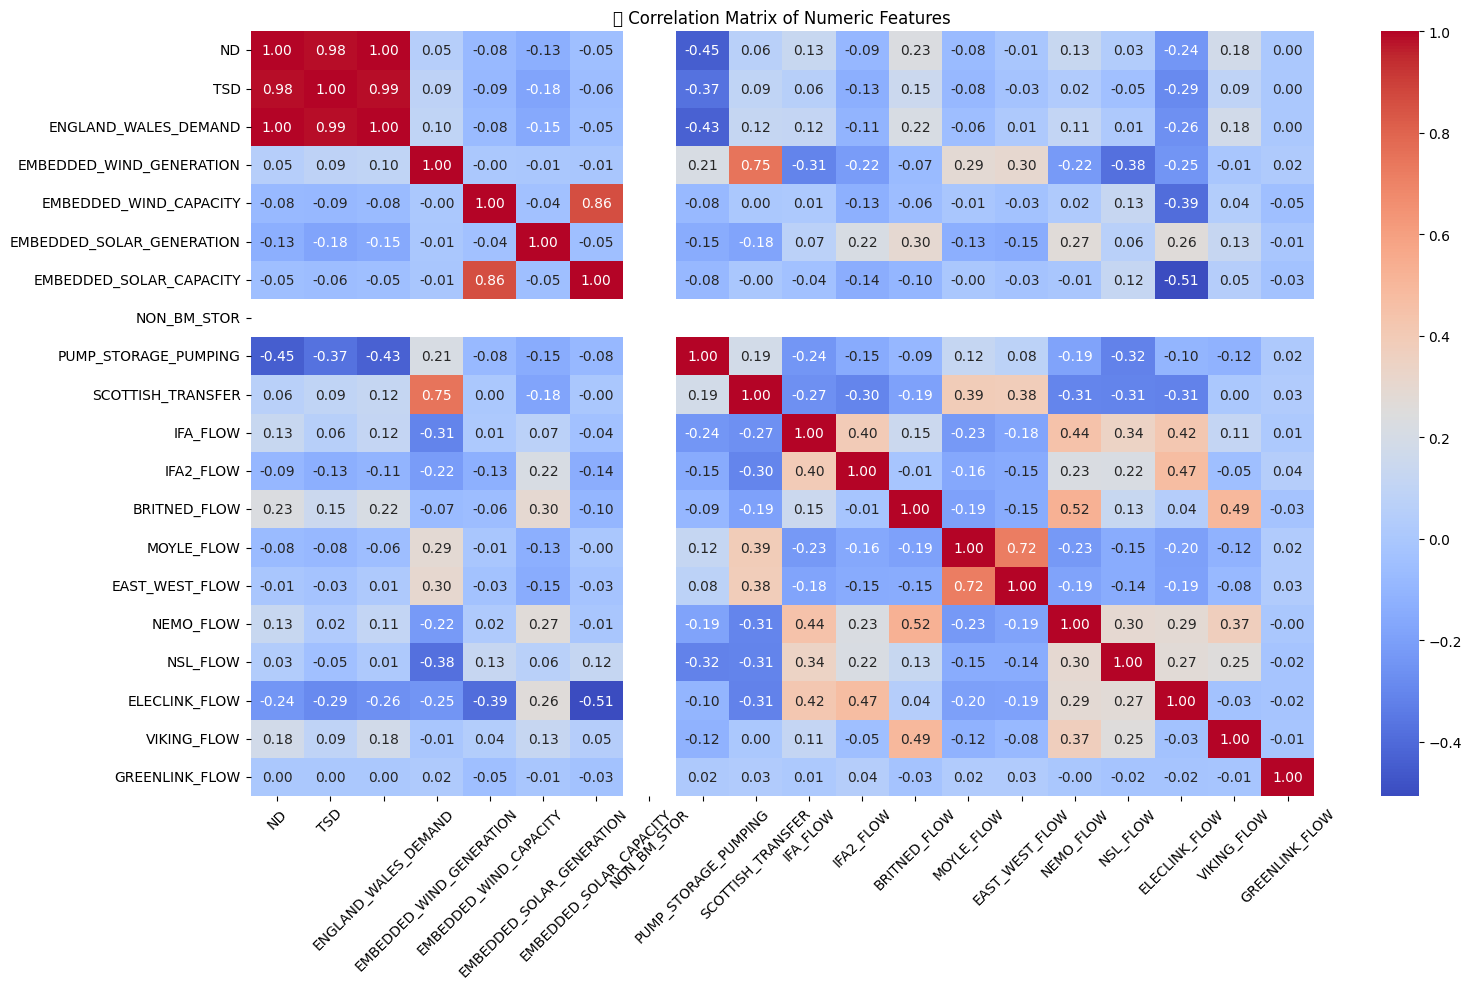

🔍 Random Forest Performance:
RMSE: 220.9741
R² Score: 0.9986


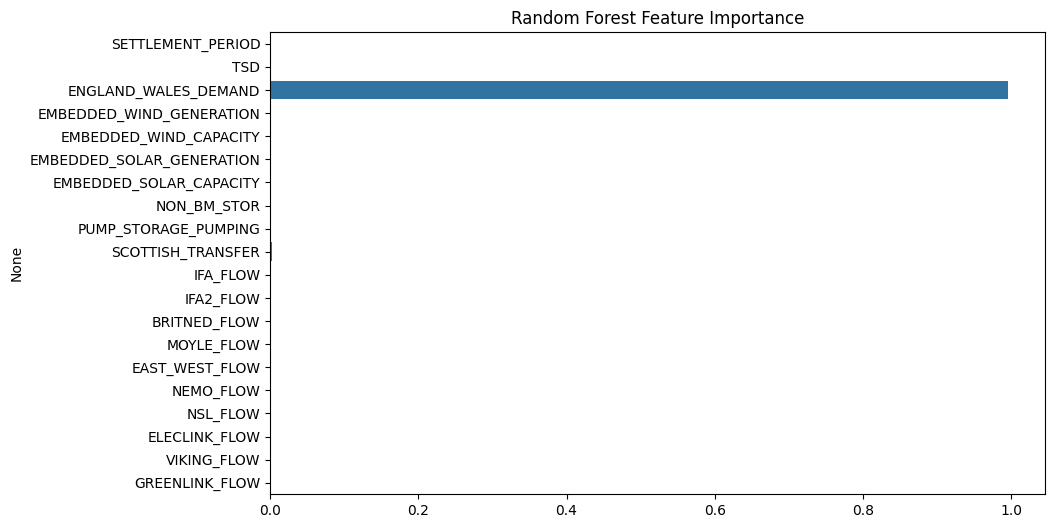

📈 Gradient Boosting Performance:
RMSE: 138.6440
R² Score: 0.9995


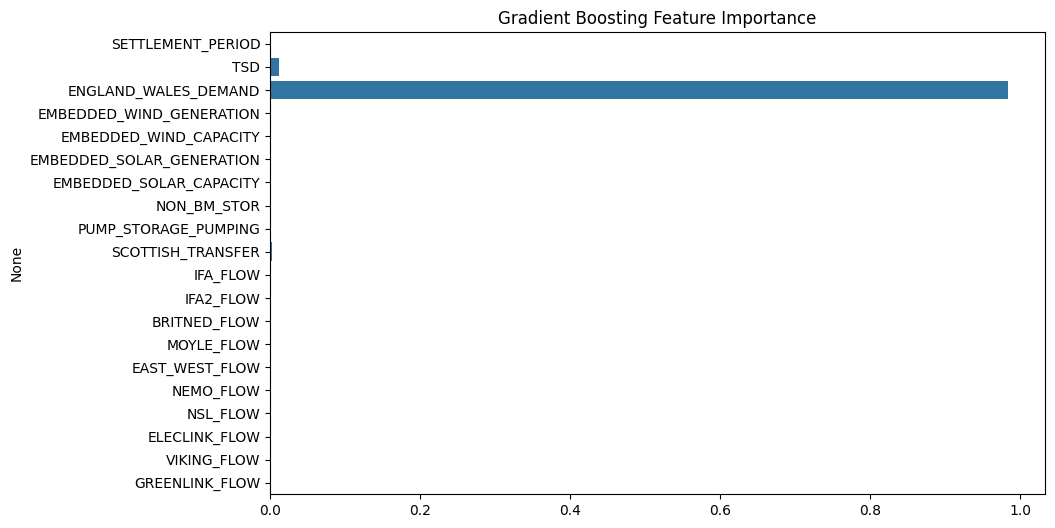

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, GridSearchCV

# Load data
df = pd.read_csv('./demanddata_2024.csv')

# Visual Exploration
plt.figure(figsize=(12, 6))
sns.lineplot(data=df[['ND', 'TSD', 'ENGLAND_WALES_DEMAND']])
plt.title('Demand Patterns Over Time')
plt.xlabel('Time (Settlement Periods)')
plt.ylabel('MW')
plt.legend(['ND', 'TSD', 'E&W Demand'])
plt.grid(True)
plt.show()

# Drop non-numeric columns for correlation
numeric_df = df.drop(columns=['SETTLEMENT_DATE', 'SETTLEMENT_PERIOD'])

# Correlation Matrix
plt.figure(figsize=(16, 10))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('🔍 Correlation Matrix of Numeric Features')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Features and target
X = df.drop(columns=['ND', 'SETTLEMENT_DATE'])
y = df['ND']

# Convert 'SETTLEMENT_PERIOD' to numeric if needed
X['SETTLEMENT_PERIOD'] = pd.to_numeric(X['SETTLEMENT_PERIOD'], errors='coerce')

# Handle any potential missing values (e.g., if conversion failed)
X = X.dropna()

# Match target values after dropping rows
y = y[X.index]

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Random Forest Regressor
rf = RandomForestRegressor(random_state=42)
rf_params = {'n_estimators': [100, 200], 'max_depth': [4, 6, 8], 'min_samples_split': [2, 5]}
grid_rf = GridSearchCV(rf, rf_params, cv=3)
grid_rf.fit(X_train, y_train)
best_rf = grid_rf.best_estimator_

y_pred_rf = best_rf.predict(X_test)

print("🔍 Random Forest Performance:")
print(f"RMSE: {mean_squared_error(y_test, y_pred_rf) ** 0.5:.4f}")
print(f"R² Score: {r2_score(y_test, y_pred_rf):.4f}")

# Feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x=best_rf.feature_importances_, y=X.columns)
plt.title('Random Forest Feature Importance')
plt.show()

# Gradient Boosting Regressor
gbm = GradientBoostingRegressor(random_state=42)
gbm_params = {'n_estimators': [100, 150], 'learning_rate': [0.05, 0.1], 'max_depth': [3, 5]}
grid_gbm = GridSearchCV(gbm, gbm_params, cv=3)
grid_gbm.fit(X_train, y_train)
best_gbm = grid_gbm.best_estimator_

y_pred_gbm = best_gbm.predict(X_test)

print("📈 Gradient Boosting Performance:")
print(f"RMSE: {mean_squared_error(y_test, y_pred_gbm) ** 0.5:.4f}")
print(f"R² Score: {r2_score(y_test, y_pred_gbm):.4f}")

# Feature importance for GBM
plt.figure(figsize=(10, 6))
sns.barplot(x=best_gbm.feature_importances_, y=X.columns)
plt.title('Gradient Boosting Feature Importance')
plt.show()


In [55]:
from pyngrok import ngrok

# Setup a tunnel to the streamlit port 8501
public_url = ngrok.connect(8501, proto="http")
print("Public URL:", public_url)

# Run the Streamlit app
!streamlit run app.py

PyngrokNgrokHTTPError: ngrok client exception, API returned 502: {"error_code":103,"status_code":502,"msg":"failed to start tunnel","details":{"err":"failed to start tunnel: session closed"}}


In [47]:
!npm install -g localtunnel



changed 22 packages in 4s

3 packages are looking for funding
  run `npm fund` for details


In [27]:
import pandas as pd
import numpy as np
import joblib
import sys
import os
import matplotlib.pyplot as plt
from datetime import datetime

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.optimizers import Adam

# Set random seeds for reproducibility
import random
import tensorflow as tf
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

def load_and_preprocess(csv_path):
    """Load data, create timestamp, fill missing values, and engineer features."""
    try:
        df = pd.read_csv(csv_path)
        print(f"Successfully loaded {len(df)} records from {csv_path}")
    except Exception as e:
        print(f"Error loading data: {e}")
        sys.exit(1)
    
    # Display basic information about the data
    print(f"Columns in the dataset: {', '.join(df.columns)}")
    print(f"Date range: {df['SETTLEMENT_DATE'].min()} to {df['SETTLEMENT_DATE'].max()}")
    
    # Combine date and period into datetime index
    df['SETTLEMENT_DATE'] = pd.to_datetime(df['SETTLEMENT_DATE'], dayfirst=True)
    # Settlement period 1 = first half-hour, so subtract 1
    df['timestamp'] = df['SETTLEMENT_DATE'] + pd.to_timedelta((df['SETTLEMENT_PERIOD'] - 1) * 30, unit='m')
    df = df.sort_values('timestamp').reset_index(drop=True)
    
    # Check for missing values before filling
    missing_before = df.isnull().sum().sum()
    
    # Fill missing values (forward-fill then mean)
    df.ffill(inplace=True)
    df.fillna(df.mean(), inplace=True)
    
    missing_after = df.isnull().sum().sum()
    print(f"Filled {missing_before} missing values. Remaining missing: {missing_after}")
    
    # Feature engineering
    # Lag features - hourly, daily, and weekly patterns
    df['ND_lag1'] = df['ND'].shift(1)  # Previous half-hour
    df['ND_lag2'] = df['ND'].shift(2)  # 1 hour before
    df['ND_lag3'] = df['ND'].shift(3)  # 1.5 hours before
    df['ND_lag48'] = df['ND'].shift(48)  # 1 day before (assuming 48 half-hours)
    df['ND_lag336'] = df['ND'].shift(336)  # 1 week before
    
    # Rolling statistics (window=6 for 3 hours, 48 for 24 hours)
    df['ND_roll_mean_3h'] = df['ND'].rolling(window=6).mean()
    df['ND_roll_std_3h'] = df['ND'].rolling(window=6).std()
    df['ND_roll_mean_24h'] = df['ND'].rolling(window=48).mean()
    df['ND_roll_std_24h'] = df['ND'].rolling(window=48).std()
    
    # Temporal features
    df['hour'] = df['timestamp'].dt.hour
    df['dayofweek'] = df['timestamp'].dt.dayofweek
    df['month'] = df['timestamp'].dt.month
    df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)
    df['is_business_hours'] = ((df['hour'] >= 9) & (df['hour'] <= 17) & (df['is_weekend'] == 0)).astype(int)
    
    # Cyclical encoding of time features
    df['hour_sin'] = np.sin(2 * np.pi * df['hour']/24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour']/24)
    df['day_sin'] = np.sin(2 * np.pi * df['dayofweek']/7)
    df['day_cos'] = np.cos(2 * np.pi * df['dayofweek']/7)
    df['month_sin'] = np.sin(2 * np.pi * df['month']/12)
    df['month_cos'] = np.cos(2 * np.pi * df['month']/12)
    
    # Drop initial rows with NaNs after lagging/rolling
    rows_before = len(df)
    df.dropna(inplace=True)
    df.reset_index(drop=True, inplace=True)
    rows_after = len(df)
    print(f"Dropped {rows_before - rows_after} rows with NaN values after feature engineering.")
    
    return df

def create_sequences(data, feature_cols, target_col, n_steps):
    """
    Create sequences of length n_steps from data for LSTM input.
    Returns X (samples, n_steps, n_features) and y (samples,).
    """
    X, y = [], []
    for i in range(len(data) - n_steps):
        X_seq = data[feature_cols].iloc[i:i+n_steps].values
        y_val = data[target_col].iloc[i+n_steps]
        X.append(X_seq)
        y.append(y_val)
    return np.array(X), np.array(y)

def build_and_train_model(X_train, y_train, X_val, y_val, n_steps, n_features, model_path='best_model.h5'):
    """Builds an improved LSTM model with bidirectional layers, trains with callbacks, and returns the model."""
    model = Sequential([
        Bidirectional(LSTM(128, return_sequences=True, dropout=0.2), input_shape=(n_steps, n_features)),
        Bidirectional(LSTM(64, dropout=0.2)),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(1)
    ])
    
    # Use class instances for optimizer and loss
    optimizer = Adam(learning_rate=0.001)
    loss = MeanSquaredError()
    
    model.compile(optimizer=optimizer, loss=loss, metrics=['mae'])
    model.summary()
    
    # Advanced callbacks
    early_stop = EarlyStopping(
        monitor='val_loss', 
        patience=10, 
        restore_best_weights=True,
        verbose=1
    )
    
    checkpoint = ModelCheckpoint(
        filepath=model_path,
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
    
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=0.0001,
        verbose=1
    )
    
    # Training with try-except to handle interruptions
    try:
        history = model.fit(
            X_train, y_train, 
            epochs=100, 
            batch_size=64, 
            validation_data=(X_val, y_val), 
            callbacks=[early_stop, checkpoint, reduce_lr], 
            verbose=2
        )
        return model, history
    except KeyboardInterrupt:
        print("\nTraining interrupted by user. Loading best saved model...")
        if os.path.exists(model_path):
            return load_model(model_path), None
        else:
            print("No saved model found. Returning current model state.")
            return model, None

def plot_history(history):
    """Plot the training and validation loss."""
    plt.figure(figsize=(12, 6))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Training History')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(loc='upper right')
    plt.grid(True)
    
    # Save the plot
    plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
    plt.close()

def plot_predictions(y_true, y_pred, title='Model Predictions vs Actual'):
    """Plot the predicted vs actual values."""
    plt.figure(figsize=(15, 8))
    plt.plot(y_true, label='Actual', alpha=0.7)
    plt.plot(y_pred, label='Predicted', alpha=0.7)
    plt.title(title)
    plt.ylabel('Energy Demand')
    plt.xlabel('Time Steps')
    plt.legend()
    plt.grid(True)
    
    # Save the plot
    filename = f"predictions_{datetime.now().strftime('%Y%m%d_%H%M%S')}.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.close()
    
    # Also plot the last 48 time steps (1 day) for more detailed view
    plt.figure(figsize=(15, 8))
    last_48 = min(48, len(y_true))
    plt.plot(y_true[-last_48:], label='Actual', alpha=0.7)
    plt.plot(y_pred[-last_48:], label='Predicted', alpha=0.7)
    plt.title(f"{title} - Last 48 Time Steps")
    plt.ylabel('Energy Demand')
    plt.xlabel('Time Steps')
    plt.legend()
    plt.grid(True)
    
    # Save the detailed plot
    filename = f"predictions_detail_{datetime.now().strftime('%Y%m%d_%H%M%S')}.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.close()

# Main execution
if __name__ == "__main__":
    # Start time
    start_time = datetime.now()
    print(f"Script started at: {start_time}")
    
    # Load and preprocess data
    input_file = 'demanddata_2024.csv'
    if not os.path.exists(input_file):
        print(f"Error: Input file '{input_file}' not found")
        sys.exit(1)
        
    df = load_and_preprocess(input_file)
    
    # Define features and target
    feature_cols = [
        'ND', 'TSD',  # Original features
        'ND_lag1', 'ND_lag2', 'ND_lag3', 'ND_lag48', 'ND_lag336',  # Lag features
        'ND_roll_mean_3h', 'ND_roll_std_3h', 'ND_roll_mean_24h', 'ND_roll_std_24h',  # Rolling features
        'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'month_sin', 'month_cos',  # Cyclical time features
        'is_weekend', 'is_business_hours'  # Binary time indicators
    ]
    target_col = 'ND'  # forecasting net demand
    
    print(f"Using {len(feature_cols)} features: {', '.join(feature_cols)}")
    
    # Split data: 70% train, 15% val, 15% test
    train_end = int(len(df) * 0.7)
    val_end = int(len(df) * 0.85)
    
    train_df = df.iloc[:train_end].reset_index(drop=True)
    val_df = df.iloc[train_end:val_end].reset_index(drop=True)
    test_df = df.iloc[val_end:].reset_index(drop=True)
    
    print(f"Data split: Training={len(train_df)} samples, Validation={len(val_df)} samples, Test={len(test_df)} samples")
    
    # Scale features
    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()
    
    # Fit scalers on training data only
    X_train_scaled = scaler_X.fit_transform(train_df[feature_cols])
    y_train_scaled = scaler_y.fit_transform(train_df[[target_col]]).ravel()
    
    # Transform validation and test data
    X_val_scaled = scaler_X.transform(val_df[feature_cols])
    y_val_scaled = scaler_y.transform(val_df[[target_col]]).ravel()
    X_test_scaled = scaler_X.transform(test_df[feature_cols])
    y_test_scaled = scaler_y.transform(test_df[[target_col]]).ravel()
    
    # Choose sequence length (12 for 6 hours of past data)
    n_steps = 12  # Increased from 6 to 12 for more context
    n_features = len(feature_cols)
    
    # Create sequences for training, validation, and testing
    X_train, y_train = create_sequences(
        pd.DataFrame(X_train_scaled, columns=feature_cols).assign(ND=y_train_scaled), 
        feature_cols, 'ND', n_steps
    )
    
    X_val, y_val = create_sequences(
        pd.DataFrame(X_val_scaled, columns=feature_cols).assign(ND=y_val_scaled),   
        feature_cols, 'ND', n_steps
    )
    
    X_test, y_test = create_sequences(
        pd.DataFrame(X_test_scaled, columns=feature_cols).assign(ND=y_test_scaled),  
        feature_cols, 'ND', n_steps
    )
    
    print(f"Training sequences: {X_train.shape}, Validation sequences: {X_val.shape}, Test sequences: {X_test.shape}")
    
    # Train the LSTM model with checkpoint saving
    model_path = 'best_lstm_model.h5'
    model, history = build_and_train_model(X_train, y_train, X_val, y_val, n_steps, n_features, model_path)
    
    # Plot training history if available
    if history:
        plot_history(history)
    
    # Load the best model (in case training was interrupted)
    if os.path.exists(model_path):
        print(f"Loading best model from {model_path}")
        model = load_model(model_path)
    
    # Evaluate on test set
    y_pred_scaled = model.predict(X_test)
    y_pred = scaler_y.inverse_transform(y_pred_scaled).ravel()
    y_true = scaler_y.inverse_transform(y_test.reshape(-1, 1)).ravel()
    
    # Calculate metrics
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100  # as percentage
    
    print(f"\nTest Set Metrics:")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE: {mae:.2f}")
    print(f"MAPE: {mape:.2f}%")
    
    # Plot predictions
    plot_predictions(y_true, y_pred, title='Energy Demand Forecast - Test Set')
    
    # Print info about TensorFlow version for diagnostics
    print(f"Using TensorFlow version: {tf.__version__}")
    
    # Save model and scalers/metadata
    try:
        model.save('lstm_model.h5')
        print("✅ Model saved successfully to lstm_model.h5")
    except Exception as e:
        print(f"❌ Error saving model: {e}")
    
    # Save scalers and metadata for later use
    try:
        metadata = {
            'scaler_X': scaler_X, 
            'scaler_y': scaler_y, 
            'n_steps': n_steps, 
            'feature_cols': feature_cols,
            'metrics': {
                'rmse': rmse,
                'mae': mae,
                'mape': mape
            },
            'train_time': str(datetime.now() - start_time)
        }
        joblib.dump(metadata, 'preprocessing_metadata.pkl')
        print("✅ Preprocessing metadata saved successfully to preprocessing_metadata.pkl")
    except Exception as e:
        print(f"❌ Error saving preprocessing metadata: {e}")
    
    # Create a simple forecast report
    with open('forecast_report.txt', 'w') as f:
        f.write("Energy Demand Forecasting Model Report\n")
        f.write("=====================================\n\n")
        f.write(f"Generated on: {datetime.now()}\n")
        f.write(f"Data from: {input_file}\n")
        f.write(f"Training time: {datetime.now() - start_time}\n\n")
        f.write("Model Architecture:\n")
        model.summary(print_fn=lambda x: f.write(x + '\n'))
        f.write("\nPerformance Metrics:\n")
        f.write(f"RMSE: {rmse:.2f}\n")
        f.write(f"MAE: {mae:.2f}\n")
        f.write(f"MAPE: {mape:.2f}%\n\n")
        f.write(f"Features used ({len(feature_cols)}):\n")
        for feat in feature_cols:
            f.write(f"- {feat}\n")
    
    print(f"\nTraining complete. Total runtime: {datetime.now() - start_time}")
    print("Model, preprocessing metadata, and report saved.")
    
# Function to make future predictions
def predict_future(model, last_data, scaler_X, scaler_y, feature_cols, n_steps, n_forecast):
    """
    Make predictions for n_forecast steps ahead using an already trained model
    
    Parameters:
    model - The trained LSTM model
    last_data - DataFrame containing the last n_steps + n_forecast rows of historical data
    scaler_X, scaler_y - The fitted scalers for features and target
    feature_cols - List of feature column names
    n_steps - Length of input sequences
    n_forecast - Number of steps to forecast into the future
    
    Returns:
    Array of predicted values
    """
    # Prepare a copy of the data for forecasting
    forecast_df = last_data.copy()
    
    # Scale the initial data
    forecast_df_scaled = pd.DataFrame(
        scaler_X.transform(forecast_df[feature_cols]),
        columns=feature_cols
    )
    
    predictions = []
    
    for i in range(n_forecast):
        # Create sequence for prediction (last n_steps)
        X_pred = np.array([forecast_df_scaled.iloc[-n_steps:].values])
        
        # Make prediction
        y_pred_scaled = model.predict(X_pred)
        
        # Inverse transform to get the actual value
        y_pred = scaler_y.inverse_transform(y_pred_scaled)[0][0]
        predictions.append(y_pred)
        
        # Create a new row for the next time step
        new_row = forecast_df.iloc[-1:].copy()
        new_row.index = [forecast_df.index[-1] + 1]
        
        # Update the timestamp
        new_row['timestamp'] = new_row['timestamp'] + pd.Timedelta(minutes=30)
        
        # Update temporal features
        new_row['hour'] = new_row['timestamp'].dt.hour
        new_row['dayofweek'] = new_row['timestamp'].dt.dayofweek
        new_row['month'] = new_row['timestamp'].dt.month
        new_row['is_weekend'] = (new_row['dayofweek'] >= 5).astype(int)
        new_row['is_business_hours'] = ((new_row['hour'] >= 9) & (new_row['hour'] <= 17) & (new_row['is_weekend'] == 0)).astype(int)
        
        # Update cyclical encoding
        new_row['hour_sin'] = np.sin(2 * np.pi * new_row['hour']/24)
        new_row['hour_cos'] = np.cos(2 * np.pi * new_row['hour']/24)
        new_row['day_sin'] = np.sin(2 * np.pi * new_row['dayofweek']/7)
        new_row['day_cos'] = np.cos(2 * np.pi * new_row['dayofweek']/7)
        new_row['month_sin'] = np.sin(2 * np.pi * new_row['month']/12)
        new_row['month_cos'] = np.cos(2 * np.pi * new_row['month']/12)
        
        # Update the ND value with our prediction
        new_row['ND'] = y_pred
        
        # Update lag features
        new_row['ND_lag1'] = forecast_df.iloc[-1]['ND']
        new_row['ND_lag2'] = forecast_df.iloc[-1]['ND_lag1'] if len(forecast_df) > 1 else forecast_df.iloc[-1]['ND']
        new_row['ND_lag3'] = forecast_df.iloc[-1]['ND_lag2'] if len(forecast_df) > 1 else forecast_df.iloc[-1]['ND']
        
        # For longer lags, use the actual historical values when available
        if len(forecast_df) >= 48:
            new_row['ND_lag48'] = forecast_df.iloc[-48]['ND']
        else:
            new_row['ND_lag48'] = forecast_df.iloc[-1]['ND_lag48'] if 'ND_lag48' in forecast_df.columns else forecast_df.iloc[-1]['ND']
            
        if len(forecast_df) >= 336:
            new_row['ND_lag336'] = forecast_df.iloc[-336]['ND']
        else:
            new_row['ND_lag336'] = forecast_df.iloc[-1]['ND_lag336'] if 'ND_lag336' in forecast_df.columns else forecast_df.iloc[-1]['ND']
        
        # Update rolling statistics (this is approximate for forecasting)
        new_window_3h = list(forecast_df.iloc[-5:]['ND']) + [y_pred]
        new_row['ND_roll_mean_3h'] = np.mean(new_window_3h)
        new_row['ND_roll_std_3h'] = np.std(new_window_3h)
        
        # For 24h rolling stats, use the existing values or calculate if we have enough data
        if len(forecast_df) >= 47:
            new_window_24h = list(forecast_df.iloc[-47:]['ND']) + [y_pred]
            new_row['ND_roll_mean_24h'] = np.mean(new_window_24h)
            new_row['ND_roll_std_24h'] = np.std(new_window_24h)
        else:
            new_row['ND_roll_mean_24h'] = forecast_df.iloc[-1]['ND_roll_mean_24h']
            new_row['ND_roll_std_24h'] = forecast_df.iloc[-1]['ND_roll_std_24h']
        
        # Append the new row to the forecast dataframe
        forecast_df = pd.concat([forecast_df, new_row])
        
        # Update the scaled version
        forecast_df_scaled = pd.DataFrame(
            scaler_X.transform(forecast_df[feature_cols]),
            columns=feature_cols
        )
    
    return np.array(predictions)

Script started at: 2025-05-02 13:23:37.424001
Successfully loaded 17568 records from demanddata_2024.csv
Columns in the dataset: SETTLEMENT_DATE, SETTLEMENT_PERIOD, ND, TSD, ENGLAND_WALES_DEMAND, EMBEDDED_WIND_GENERATION, EMBEDDED_WIND_CAPACITY, EMBEDDED_SOLAR_GENERATION, EMBEDDED_SOLAR_CAPACITY, NON_BM_STOR, PUMP_STORAGE_PUMPING, SCOTTISH_TRANSFER, IFA_FLOW, IFA2_FLOW, BRITNED_FLOW, MOYLE_FLOW, EAST_WEST_FLOW, NEMO_FLOW, NSL_FLOW, ELECLINK_FLOW, VIKING_FLOW, GREENLINK_FLOW
Date range: 01-APR-2024 to 31-OCT-2024
Filled 0 missing values. Remaining missing: 0
Dropped 336 rows with NaN values after feature engineering.
Using 19 features: ND, TSD, ND_lag1, ND_lag2, ND_lag3, ND_lag48, ND_lag336, ND_roll_mean_3h, ND_roll_std_3h, ND_roll_mean_24h, ND_roll_std_24h, hour_sin, hour_cos, day_sin, day_cos, month_sin, month_cos, is_weekend, is_business_hours
Data split: Training=12062 samples, Validation=2585 samples, Test=2585 samples


C:\Users\DELL\AppData\Local\Temp\ipykernel_36300\809587591.py:38: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['SETTLEMENT_DATE'] = pd.to_datetime(df['SETTLEMENT_DATE'], dayfirst=True)


KeyboardInterrupt: 

In [34]:
from pyngrok import ngrok

# Setup a tunnel to the streamlit port 8501
public_url = ngrok.connect(8501, proto="http")
print("Public URL:", public_url)

# Run the Streamlit app
!streamlit run app.py

PyngrokNgrokHTTPError: ngrok client exception, API returned 502: {"error_code":103,"status_code":502,"msg":"failed to start tunnel","details":{"err":"failed to start tunnel: session closed"}}
